# Predicting CYP2C19 Inhibition: A Machine Learning Approach
**Objective:** Apply machine learning methods to predict whether a molecule inhibits the CYP2C19 enzyme, a crucial protein involved in drug metabolism.
**Dataset:** The Veith et al. dataset (via TDC), consisting of robust inhibitor and non-inhibitor classifications.

**Methodology:**
1. Data cleaning and SMILES validation.
2. Feature engineering (Physicochemical descriptors vs. Morgan Fingerprints).
3. Model implementation with validation-based hyperparameter tuning across Train, Valid, and Test splits.
4. Feature subset evaluation and Dimensionality Reduction.
5. Model explainability (SHAP) and Applicability Domain (AD) assessment.

In [1]:
# =============================================================================
"""Core imports used throughout the notebook."""
# =============================================================================
import sys
import time
import warnings

# =============================================================================
# Data handling and numerical computing
# =============================================================================
import numpy as np
import pandas as pd

# =============================================================================
# Visualization
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# =============================================================================
# Machine learning
# =============================================================================
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, roc_curve, precision_recall_curve, r2_score
)
from xgboost import XGBClassifier

# =============================================================================
# Cheminformatics
# =============================================================================
from rdkit import Chem, RDLogger, DataStructs
from rdkit.Chem import AllChem, Descriptors, Crippen, Fragments, Draw
from rdkit.Chem.rdMolDescriptors import CalcTPSA

# =============================================================================
# Notebook configuration
# =============================================================================
warnings.filterwarnings('ignore')
RDLogger.DisableLog('rdApp.*')
random_state = 42
sys.path.insert(0, '.')

In [2]:
from tdc.single_pred import ADME
data = ADME(name = 'CYP2C19_Veith')
split = data.get_split()

Found local copy...
Loading...
Done!


### Data Cleaning and Scaffold Preservation
TDC provides pre-computed `train`, `valid`, and `test` splits based on molecular scaffolds. Preserving this scaffold split is critical to ensure our model is evaluated on its ability to generalize to novel chemical spaces, rather than simply memorizing fragments from structurally identical analogs. 

Here, we independently validate the SMILES strings and remove duplicates *within* each pre-defined split to completely prevent data leakage.

In [3]:
from rdkit import Chem

# Extract original scaffold splits
train_raw = split['train']
valid_raw = split['valid']
test_raw = split['test']

def clean_split(df, name="Split"):
    """Validates SMILES and removes duplicates within a specific split."""
    initial_count = len(df)
    
    # 1. Validate SMILES
    valid_mask = df['Drug'].apply(lambda x: Chem.MolFromSmiles(x) is not None)
    df_valid = df[valid_mask].copy()
    
    # 2. Canonicalize for strict duplicate removal
    df_valid['Canonical_SMILES'] = df_valid['Drug'].apply(
        lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x), canonical=True)
    )
    
    # 3. Drop duplicates
    df_unique = df_valid.drop_duplicates(subset=['Canonical_SMILES']).reset_index(drop=True)
    df_final = df_unique.drop(columns=['Canonical_SMILES'])
    
    print(f"{name} -> Original: {initial_count} | Valid & Unique: {len(df_final)}")
    return df_final

def enforce_no_overlap(train_df, valid_df, test_df):
    """Remove cross-split duplicates (based on canonical SMILES) to avoid leakage."""
    def _canonical_series(df):
        return df['Drug'].apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x), canonical=True))
    
    train_can = _canonical_series(train_df)
    valid_can = _canonical_series(valid_df)
    test_can = _canonical_series(test_df)
    
    overlap_train_valid = set(train_can) & set(valid_can)
    overlap_train_test = set(train_can) & set(test_can)
    overlap_valid_test = set(valid_can) & set(test_can)
    
    print("=== Cross-Split Overlap Check ===")
    print(f"Train ∩ Valid: {len(overlap_train_valid)}")
    print(f"Train ∩ Test : {len(overlap_train_test)}")
    print(f"Valid ∩ Test : {len(overlap_valid_test)}")
    
    # Remove overlaps to keep splits mutually exclusive
    valid_keep = ~valid_can.isin(train_can)
    test_keep = ~(test_can.isin(train_can) | test_can.isin(valid_can))
    
    valid_df_clean = valid_df.loc[valid_keep].reset_index(drop=True)
    test_df_clean = test_df.loc[test_keep].reset_index(drop=True)
    
    print(f"Removed from Valid: {len(valid_df) - len(valid_df_clean)}")
    print(f"Removed from Test : {len(test_df) - len(test_df_clean)}")
    return valid_df_clean, test_df_clean

print("=== Scaffold-Preserving Data Cleaning ===")
train_df = clean_split(train_raw, "Train")
valid_df = clean_split(valid_raw, "Valid")
test_df  = clean_split(test_raw,  "Test")

# Remove any cross-split overlaps to eliminate leakage
valid_df, test_df = enforce_no_overlap(train_df, valid_df, test_df)

df_final = pd.concat([train_df, valid_df, test_df], ignore_index=True)

=== Scaffold-Preserving Data Cleaning ===
Train -> Original: 8866 | Valid & Unique: 8866
Valid -> Original: 1266 | Valid & Unique: 1266
Test -> Original: 2533 | Valid & Unique: 2533
=== Cross-Split Overlap Check ===
Train ∩ Valid: 0
Train ∩ Test : 0
Valid ∩ Test : 0
Removed from Valid: 0
Removed from Test : 0


## 1. Exploratory Data Analysis (EDA)

We inspect the cleaned, scaffold-preserved splits before any feature engineering so the dataset structure is understood independently of descriptors and fingerprints.

In [4]:
# Quick overview before feature engineering
class_counts = pd.DataFrame({
    'Split': ['Train', 'Valid', 'Test'],
    'Inhibitor': [int((train_df['Y'] == 1).sum()), int((valid_df['Y'] == 1).sum()), int((test_df['Y'] == 1).sum())],
    'Non-Inhibitor': [int((train_df['Y'] == 0).sum()), int((valid_df['Y'] == 0).sum()), int((test_df['Y'] == 0).sum())],
})

display(class_counts)

df_final['smiles_length'] = df_final['Drug'].apply(len)
print('=== EDA Summary ===')
print(f"Total molecules: {len(df_final)}")
print(f"Inhibitors: {int((df_final['Y'] == 1).sum())} ({100*(df_final['Y'] == 1).mean():.1f}%)")
print(f"Non-inhibitors: {int((df_final['Y'] == 0).sum())} ({100*(df_final['Y'] == 0).mean():.1f}%)")
print(f"SMILES length mean: {df_final['smiles_length'].mean():.1f}")
print(f"SMILES length range: {df_final['smiles_length'].min()} - {df_final['smiles_length'].max()}")


,Split,Inhibitor,Non-Inhibitor
0,Train,4063,4803
1,Valid,593,673
2,Test,1163,1370


=== EDA Summary ===
Total molecules: 12665
Inhibitors: 5819 (45.9%)
Non-inhibitors: 6846 (54.1%)
SMILES length mean: 46.1
SMILES length range: 2 - 340


## References: Descriptor Selection and Justification

The feature engineering phase of this project utilized a combination of fundamental pharmacokinetic properties, structural complexity indices, and topological proxies to model CYP2C19 inhibition[cite: 1]. The inclusion of these specific descriptors is grounded in the following foundational cheminformatics literature:

### 1. Dataset Origin & CYP Inhibition
* **Veith Dataset:** Veith, H., et al. (2009). "Comprehensive Predictability of Cytochrome P450 Inhibition from in Silico High-Throughput Screening Data." *Nature Biotechnology*, 27(11), 1050-1055. 
  *(Use this to justify the baseline choice of predicting CYP2C19 using 1D/2D structural data).*

### 2. Pharmacokinetic Baseline (Absorption & Permeability)
* **Lipinski’s Rule of Five (`mol_wt`, `logp`, `hbond_donor`, `hbond_acceptor`):** Lipinski, C. A., et al. (1997). "Experimental and computational approaches to estimate solubility and permeability in drug discovery and development settings." *Advanced Drug Delivery Reviews*, 23(1-3), 3-25.
* **Veber Rules (`tpsa`, `num_rotatable_bonds`):** Veber, D. F., et al. (2002). "Molecular properties that influence the oral bioavailability of drug candidates." *Journal of Medicinal Chemistry*, 45(12), 2615-2623.

### 3. 3D Shape, Spherocity, and Steric Bulk Proxies
* **Fraction Csp3 (`fraction_csp3`):** Lovering, F., Bikker, J., & Humblet, C. (2009). "Escape from Flatland: Increasing Saturation as an Approach to Improving Clinical Success." *Journal of Medicinal Chemistry*, 52(21), 6752–6756.
  *(This is the seminal paper proving that counting sp3 carbons is a valid proxy for 3D molecular shape and clinical success).*
* **Labute's Approximate Surface Area (`labute_asa`):** Labute, P. (2000). "A widely applicable set of descriptors." *Journal of Molecular Graphics and Modelling*, 18(4-5), 464-477.

### 4. Topological Branching & Molecular Complexity
* **Balaban J Index (`balaban_j`):** Balaban, A. T. (1982). "Highly discriminating distance-based topological index." *Chemical Physics Letters*, 89(5), 399-404.
* **Bertz CT (`bertz_ct`):** Bertz, S. H. (1981). "The first general index of molecular complexity." *Journal of the American Chemical Society*, 103(12), 3599-3601.

### 5. Electronic Properties & Polarizability
* **Molar Refractivity (`mol_mr`):** Wildman, S. A., & Crippen, G. M. (1999). "Prediction of physicochemical parameters by atomic contributions." *Journal of Chemical Information and Computer Sciences*, 39(5), 868-873.
* **Partial Charges (`max_partial_charge`, `min_partial_charge`):** Gasteiger, J., & Marsili, M. (1980). "Iterative partial equalization of orbital electronegativities—a rapid access to atomic charges." *Tetrahedron*, 36(22), 3219-3228.

In [5]:
SELECTED_DESCRIPTOR_NAMES = [
    # --- Original Literature Standard Core ---
    'logp',
    'mol_wt',
    'hbond_donor',
    'hbond_acceptor',
    'tpsa',
    'num_rotatable_bonds',
    
    # --- Additional structural fragment features ---
    'num_aromatic_rings',
    'fr_Al_OH',
    'fr_NH2',
    'fr_COO2',
    
    # --- Original Electronic properties ---
    'max_partial_charge',
    'min_partial_charge',
    'num_heteroatoms',
    
    # ==========================================
    # --- Halogenation ---
    'fr_halogen',      # Counts all halogens (F, Cl, Br, I) - a useful structural descriptor
    
    # --- Shape & Steric Bulk (2D Proxies) ---
    'fraction_csp3',   # Fraction of sp3 carbons: Measures how "3D" or spherical a molecule is
    'labute_asa',      # Labute's Approximate Surface Area: Proxy for molecular volume
    
    # --- Topological Branching ---
    'balaban_j',       # Balaban J Index: Measures topological branching and shape
    'bertz_ct',        # Bertz CT: A highly regarded molecular complexity index
    
    # --- Advanced Electronic Proxy ---
    'mol_mr'           # Molar Refractivity: Measures total polarizability and electron cloud distortion
]

def smiles2physchem_selected(smiles: str) -> list:
    """
    Compute an expanded descriptor set including core ADME, structural fragment counts, 
    halogens, and 2D proxies for shape and polarizability.
    """
    molecule = Chem.MolFromSmiles(smiles)
    if molecule is None:
        return [None] * len(SELECTED_DESCRIPTOR_NAMES)
        
    AllChem.ComputeGasteigerCharges(molecule)
    
    return [
        # Original core
        Crippen.MolLogP(molecule),
        Descriptors.MolWt(molecule),
        Descriptors.NumHDonors(molecule),
        Descriptors.NumHAcceptors(molecule),
        CalcTPSA(molecule),
        Descriptors.NumRotatableBonds(molecule),
        
        # Additional structural fragment features
        Descriptors.NumAromaticRings(molecule),
        Fragments.fr_Al_OH(molecule),
        Fragments.fr_NH2(molecule),
        Fragments.fr_COO2(molecule),
        
        # Original Electronics
        Descriptors.MaxPartialCharge(molecule),
        Descriptors.MinPartialCharge(molecule),
        Descriptors.NumHeteroatoms(molecule),
        
        # --- Additional shape / electronic descriptors ---
        Fragments.fr_halogen(molecule),
        Descriptors.FractionCSP3(molecule),
        Descriptors.LabuteASA(molecule),
        Descriptors.BalabanJ(molecule),
        Descriptors.BertzCT(molecule),
        Crippen.MolMR(molecule)
    ]

# Backward-compatible aliases for any downstream cells
DESCRIPTOR_NAMES = SELECTED_DESCRIPTOR_NAMES
smiles2physchem_extended = smiles2physchem_selected

### Feature Selection: Removing Multicollinearity
Highly correlated features provide redundant information and can destabilize certain models (like Logistic Regression). We calculate the Spearman correlation matrix for our 19 descriptors. Any feature with a correlation higher than 0.85 with another feature is dropped to ensure our feature space remains lean and independent.

In [6]:
# Compute selected descriptors and prune highly correlated features on the training split
def build_descriptor_frame(df):
    descriptor_values = df['Drug'].apply(smiles2physchem_selected)
    descriptor_df = pd.DataFrame(descriptor_values.tolist(), columns=SELECTED_DESCRIPTOR_NAMES, index=df.index)
    return pd.concat([df.copy(), descriptor_df], axis=1)

train_desc_df = build_descriptor_frame(train_df)
valid_desc_df = build_descriptor_frame(valid_df)
test_desc_df = build_descriptor_frame(test_df)

correlation_threshold = 0.85
descriptor_corr = train_desc_df[SELECTED_DESCRIPTOR_NAMES].corr(method='spearman').abs()
upper_triangle = descriptor_corr.where(np.triu(np.ones(descriptor_corr.shape), k=1).astype(bool))
features_to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > correlation_threshold)]
final_feature_columns = [feature for feature in SELECTED_DESCRIPTOR_NAMES if feature not in features_to_drop]

X_train = train_desc_df[final_feature_columns].copy()
X_valid = valid_desc_df[final_feature_columns].copy()
X_test = test_desc_df[final_feature_columns].copy()
y_train = train_desc_df['Y'].copy()
y_valid = valid_desc_df['Y'].copy()
y_test = test_desc_df['Y'].copy()

print('=== Feature Selection Summary ===')
print(f'Initial descriptor count: {len(SELECTED_DESCRIPTOR_NAMES)}')
print(f'Correlation threshold: {correlation_threshold}')
print(f'Dropped for multicollinearity: {features_to_drop}')
print(f'Final feature count: {len(final_feature_columns)}')
print(f'Final features: {final_feature_columns}')

=== Feature Selection Summary ===
Initial descriptor count: 19
Correlation threshold: 0.85
Dropped for multicollinearity: ['labute_asa', 'mol_mr']
Final feature count: 17
Final features: ['logp', 'mol_wt', 'hbond_donor', 'hbond_acceptor', 'tpsa', 'num_rotatable_bonds', 'num_aromatic_rings', 'fr_Al_OH', 'fr_NH2', 'fr_COO2', 'max_partial_charge', 'min_partial_charge', 'num_heteroatoms', 'fr_halogen', 'fraction_csp3', 'balaban_j', 'bertz_ct']


In [7]:
train_desc_df

,Drug_ID,Drug,Y,logp,mol_wt,hbond_donor,hbond_acceptor,tpsa,num_rotatable_bonds,num_aromatic_rings,...,fr_COO2,max_partial_charge,min_partial_charge,num_heteroatoms,fr_halogen,fraction_csp3,labute_asa,balaban_j,bertz_ct,mol_mr
0,644675.0,CC(=O)N(c1ccc2oc(=O)sc2c1)S(=O)(=O)c1cccs1,1,2.65780,355.418,0,7,84.66,3,3,...,0,0.395588,-0.413988,9,0,0.076923,132.829243,2.180823,997.906575,85.0258
1,644851.0,Clc1ccccc1-c1nc(-c2ccccc2)n[nH]1,1,3.79210,255.708,1,2,41.57,2,3,...,0,0.180998,-0.258611,4,1,0.000000,109.465768,2.027803,661.565659,72.2647
2,644968.0,COc1ccccc1CNC(=O)Cn1nnc(-c2ccncc2)n1,1,1.06010,324.344,1,7,94.82,6,3,...,0,0.243448,-0.496407,8,0,0.187500,138.033374,1.584976,818.199663,85.8887
3,645063.0,CC(=O)Nc1cccc(NC(=O)C2CCCN2C(=O)Nc2ccccc2C)c1,0,3.58842,380.448,3,3,90.54,4,2,...,0,0.322037,-0.326261,7,0,0.285714,163.661132,1.666028,896.724363,109.3011
4,645164.0,CCC(c1nnnn1CC1CCCO1)N(CCN1CCOCC1)Cc1cc2cc(C)cc...,0,2.28752,495.628,1,9,101.40,10,3,...,0,0.252440,-0.378793,10,0,0.615385,211.108938,1.424725,1197.711124,136.7977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8861,16758808.0,O=C1C=C[C@@H](O)[C@@H]2[C@@H]1CC[C@H]1C(=O)N(C...,0,1.04250,369.373,1,6,93.14,2,1,...,0,0.233325,-0.453595,7,0,0.450000,155.093389,1.430165,877.222954,91.4698
8862,16758811.0,CCOC(=O)CCN1C(=O)[C@@H]2[C@@H](CC[C@@H]3C(=O)C...,0,0.06680,335.356,1,6,100.98,4,0,...,0,0.307089,-0.465920,7,0,0.647059,139.184929,1.780962,612.202025,81.3178
8863,16758814.0,CCN1C(=O)[C@@H]2[C@@H](CC[C@@H]3C(=O)C=C[C@@H]...,0,0.13350,263.293,1,4,74.68,1,0,...,0,0.232996,-0.388692,5,0,0.642857,110.815036,1.996452,483.837636,65.7418
8864,16758816.0,O=C1[C@H]2CC=C3[C@@H]([C@H](O)[C@H]4O[C@@H]4C3...,0,1.00920,397.427,1,6,88.60,2,1,...,0,0.233632,-0.389652,7,0,0.545455,167.769465,1.356116,891.823381,99.0888


### Baseline Representation: Morgan Fingerprints (ECFP4)
To benchmark our curated physicochemical descriptor set, we generate Extended-Connectivity Fingerprints (ECFP4). ECFP4 hashes the local structural neighborhood of every atom (up to a radius of 2 bonds) into a 1024-bit binary vector. While highly dimensional and sparse, this is the industry standard for capturing 2D molecular topology.

In [8]:
# Add Morgan fingerprints (ECFP4) as a structural benchmark
MORGAN_RADIUS = 2  # ECFP4
MORGAN_NBITS = 1024

def smiles_to_morgan_fp(smiles: str, n_bits: int = MORGAN_NBITS, radius: int = MORGAN_RADIUS) -> np.ndarray:
    mol = Chem.MolFromSmiles(smiles)
    fp_array = np.zeros((n_bits,), dtype=np.int8)
    if mol is None:
        return fp_array
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    DataStructs.ConvertToNumpyArray(fp, fp_array)
    return fp_array

def build_morgan_frame(df):
    fp_matrix = np.vstack(df['Drug'].apply(smiles_to_morgan_fp).to_numpy())
    fp_columns = [f'ecfp4_{i}' for i in range(MORGAN_NBITS)]
    return pd.DataFrame(fp_matrix, columns=fp_columns, index=df.index)

train_fp_df = build_morgan_frame(train_df)
valid_fp_df = build_morgan_frame(valid_df)
test_fp_df = build_morgan_frame(test_df)

# Curated descriptors + fingerprints = strong benchmark representation
X_train_benchmark = pd.concat([X_train, train_fp_df], axis=1)
X_valid_benchmark = pd.concat([X_valid, valid_fp_df], axis=1)
X_test_benchmark = pd.concat([X_test, test_fp_df], axis=1)

print('=== Morgan Fingerprint Benchmark ===')
print(f'Fingerprint length: {MORGAN_NBITS} bits')
print(f'ECFP radius: {MORGAN_RADIUS} (ECFP4)')
print(f'Benchmark feature count: {X_train_benchmark.shape[1]}')
print(f'Curated descriptors kept: {X_train.shape[1]}')
print(f'Fingerprint bits added: {train_fp_df.shape[1]}')

=== Morgan Fingerprint Benchmark ===
Fingerprint length: 1024 bits
ECFP radius: 2 (ECFP4)
Benchmark feature count: 1041
Curated descriptors kept: 17
Fingerprint bits added: 1024


## Extended EDA and Chemical Space Analysis
The deeper plots below examine class balance, SMILES length, descriptor distributions, and representative structures after the initial top-level EDA overview.

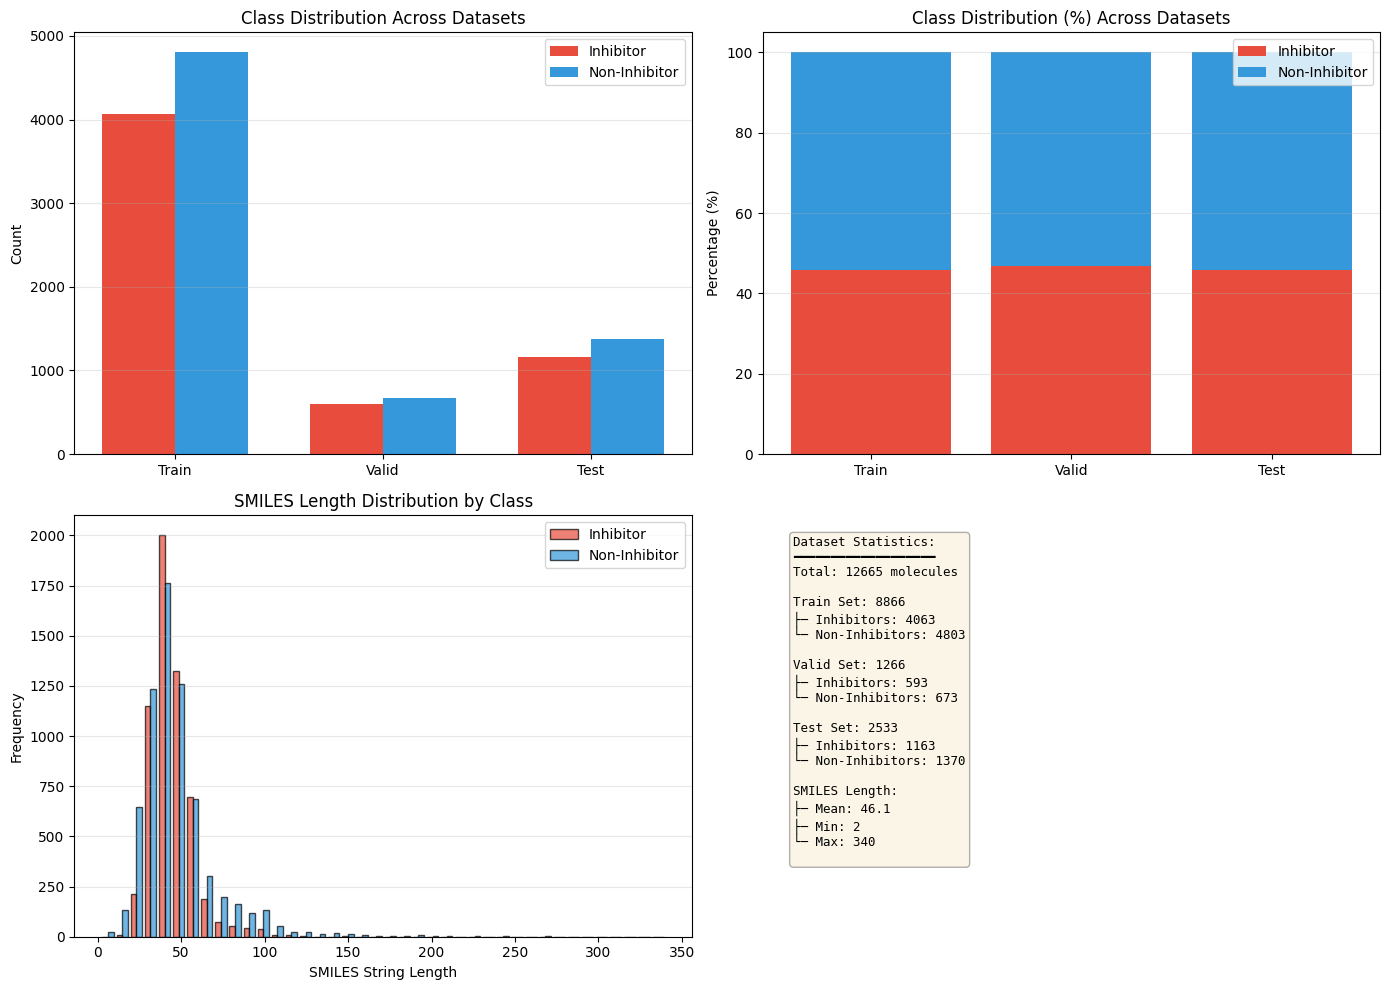

In [9]:
# Class Distribution Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Class distribution across datasets
datasets = ['Train', 'Valid', 'Test']
inhibitor_counts = [
    sum(train_df['Y'] == 1),
    sum(valid_df['Y'] == 1),
    sum(test_df['Y'] == 1)
]
non_inhibitor_counts = [
    sum(train_df['Y'] == 0),
    sum(valid_df['Y'] == 0),
    sum(test_df['Y'] == 0)
]

x = np.arange(len(datasets))
width = 0.35
axes[0, 0].bar(x - width/2, inhibitor_counts, width, label='Inhibitor', color='#e74c3c')
axes[0, 0].bar(x + width/2, non_inhibitor_counts, width, label='Non-Inhibitor', color='#3498db')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Class Distribution Across Datasets')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(datasets)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Percentage stacked bar
dataset_sizes = [len(train_df), len(valid_df), len(test_df)]
percentages_inhibitor = [c / size * 100 for c, size in zip(inhibitor_counts, dataset_sizes)]
percentages_non = [100 - p for p in percentages_inhibitor]

axes[0, 1].bar(datasets, percentages_inhibitor, label='Inhibitor', color='#e74c3c')
axes[0, 1].bar(datasets, percentages_non, bottom=percentages_inhibitor, 
               label='Non-Inhibitor', color='#3498db')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].set_title('Class Distribution (%) Across Datasets')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. SMILES length distribution
df_final['smiles_length'] = df_final['Drug'].apply(len)

axes[1, 0].hist([df_final[df_final['Y']==1]['smiles_length'],
                 df_final[df_final['Y']==0]['smiles_length']],
                bins=40, label=['Inhibitor', 'Non-Inhibitor'], 
                color=['#e74c3c', '#3498db'], alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('SMILES String Length')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('SMILES Length Distribution by Class')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. Statistics summary
stats_text = f"""Dataset Statistics:
━━━━━━━━━━━━━━━━━━━
Total: {len(df_final)} molecules

Train Set: {len(train_df)}
├─ Inhibitors: {sum(train_df['Y']==1)}
└─ Non-Inhibitors: {sum(train_df['Y']==0)}

Valid Set: {len(valid_df)}
├─ Inhibitors: {sum(valid_df['Y']==1)}
└─ Non-Inhibitors: {sum(valid_df['Y']==0)}

Test Set: {len(test_df)}
├─ Inhibitors: {sum(test_df['Y']==1)}
└─ Non-Inhibitors: {sum(test_df['Y']==0)}

SMILES Length:
├─ Mean: {df_final['smiles_length'].mean():.1f}
├─ Min: {df_final['smiles_length'].min()}
└─ Max: {df_final['smiles_length'].max()}
"""
axes[1, 1].text(0.05, 0.95, stats_text, transform=axes[1, 1].transAxes,
                fontfamily='monospace', fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()



In [10]:
print("=== EDA Summary ===")
print(f"Inhibitors: {sum(df_final['Y']==1)} ({100*sum(df_final['Y']==1)/len(df_final):.1f}%)")
print(f"Non-Inhibitors: {sum(df_final['Y']==0)} ({100*sum(df_final['Y']==0)/len(df_final):.1f}%)")
print(f"SMILES Length - Mean: {df_final['smiles_length'].mean():.1f}, Std: {df_final['smiles_length'].std():.1f}")

=== EDA Summary ===
Inhibitors: 5819 (45.9%)
Non-Inhibitors: 6846 (54.1%)
SMILES Length - Mean: 46.1, Std: 20.0


In [11]:
# Compute molecular descriptors
def compute_descriptors(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            return {
                'MW': Descriptors.MolWt(mol),
                'LogP': Descriptors.MolLogP(mol),
                'HBD': Descriptors.NumHDonors(mol),
                'HBA': Descriptors.NumHAcceptors(mol),
                'RotBonds': Descriptors.NumRotatableBonds(mol),
                'Rings': Descriptors.RingCount(mol)
            }
    except:
        pass
    return {k: np.nan for k in ['MW', 'LogP', 'HBD', 'HBA', 'RotBonds', 'Rings']}

In [12]:
print("Computing molecular descriptors... (this may take a moment)")
descriptors_list = df_final['Drug'].apply(compute_descriptors)
descriptors_df = pd.DataFrame(list(descriptors_list))
all_data_with_desc = pd.concat([df_final, descriptors_df], axis=1) 


Computing molecular descriptors... (this may take a moment)


Before feeding features into a model, we must visualize their distributions to ensure there are no extreme outliers and to identify broad chemical trends separating our two classes.


Molecular Weight:
  Inhibitors - Mean: 367.30, Std: 83.26
  Non-Inhibitors - Mean: 347.72, Std: 122.72

LogP (Lipophilicity):
  Inhibitors - Mean: 3.72, Std: 1.30
  Non-Inhibitors - Mean: 2.31, Std: 2.09

H-Bond Donors:
  Inhibitors - Mean: 0.99, Std: 0.86
  Non-Inhibitors - Mean: 1.44, Std: 1.54

H-Bond Acceptors:
  Inhibitors - Mean: 4.72, Std: 1.81
  Non-Inhibitors - Mean: 5.08, Std: 2.62

Rotatable Bonds:
  Inhibitors - Mean: 4.84, Std: 2.25
  Non-Inhibitors - Mean: 4.26, Std: 2.72

Ring Count:
  Inhibitors - Mean: 3.32, Std: 1.15
  Non-Inhibitors - Mean: 3.03, Std: 1.49


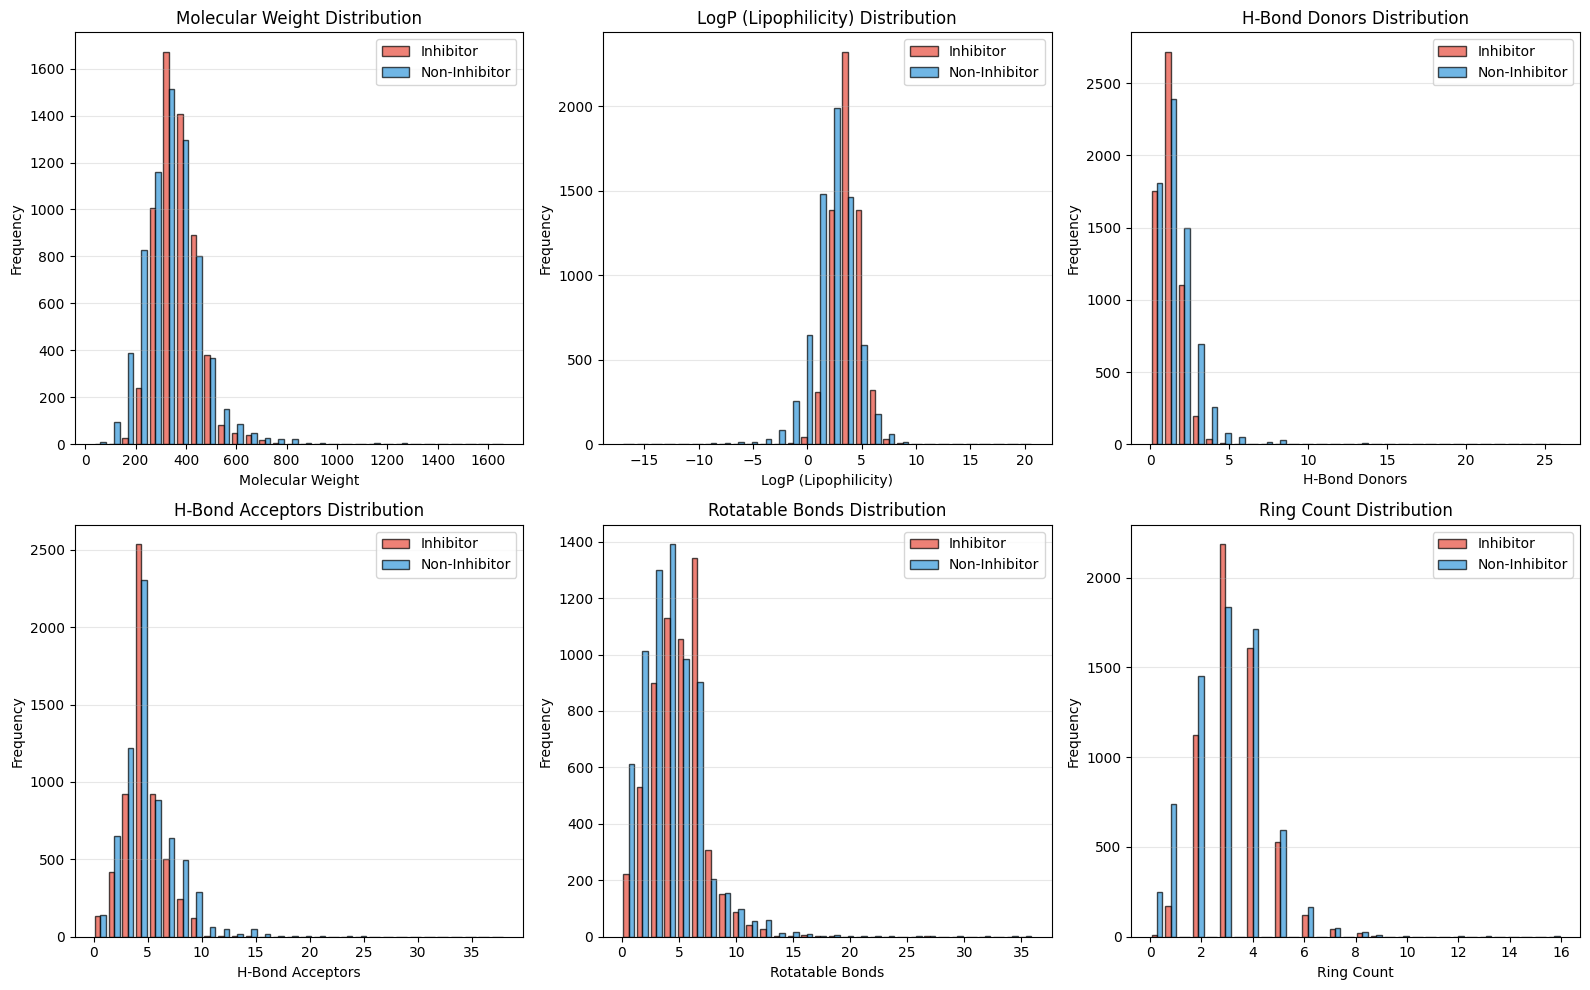

In [13]:

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

properties = ['MW', 'LogP', 'HBD', 'HBA', 'RotBonds', 'Rings']
titles = ['Molecular Weight', 'LogP (Lipophilicity)', 'H-Bond Donors', 
          'H-Bond Acceptors', 'Rotatable Bonds', 'Ring Count']

for idx, (prop, title) in enumerate(zip(properties, titles)):
    inhibitors = all_data_with_desc[all_data_with_desc['Y'] == 1][prop]
    non_inhibitors = all_data_with_desc[all_data_with_desc['Y'] == 0][prop]
    
    axes[idx].hist([inhibitors, non_inhibitors], bins=30, 
                   label=['Inhibitor', 'Non-Inhibitor'],
                   color=['#e74c3c', '#3498db'], alpha=0.7, edgecolor='black')
    axes[idx].set_xlabel(title)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{title} Distribution')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3, axis='y')
    
    # Print statistics
    print(f"\n{title}:")
    print(f"  Inhibitors - Mean: {inhibitors.mean():.2f}, Std: {inhibitors.std():.2f}")
    print(f"  Non-Inhibitors - Mean: {non_inhibitors.mean():.2f}, Std: {non_inhibitors.std():.2f}")

plt.tight_layout()
plt.show()

*   **LogP (Lipophilicity) & Molecular Weight:** Inhibitors generally skew slightly heavier and more lipophilic (higher LogP) than non-inhibitors. This aligns with the biological reality of CYP2C19, which features a highly hydrophobic binding pocket.
*   **Hydrogen Bonding:** Inhibitors tend to have fewer Hydrogen Bond Donors compared to non-inhibitors. 
*   **Ring Count:** Inhibitors display a slight shift toward higher ring counts, reinforcing the preference for bulky, aromatic structures in the active site.

High collinearity (features that are too highly correlated) can destabilize certain machine learning algorithms, particularly linear models like Logistic Regression. We use Spearman correlation to capture both linear and non-linear monotonic relationships.

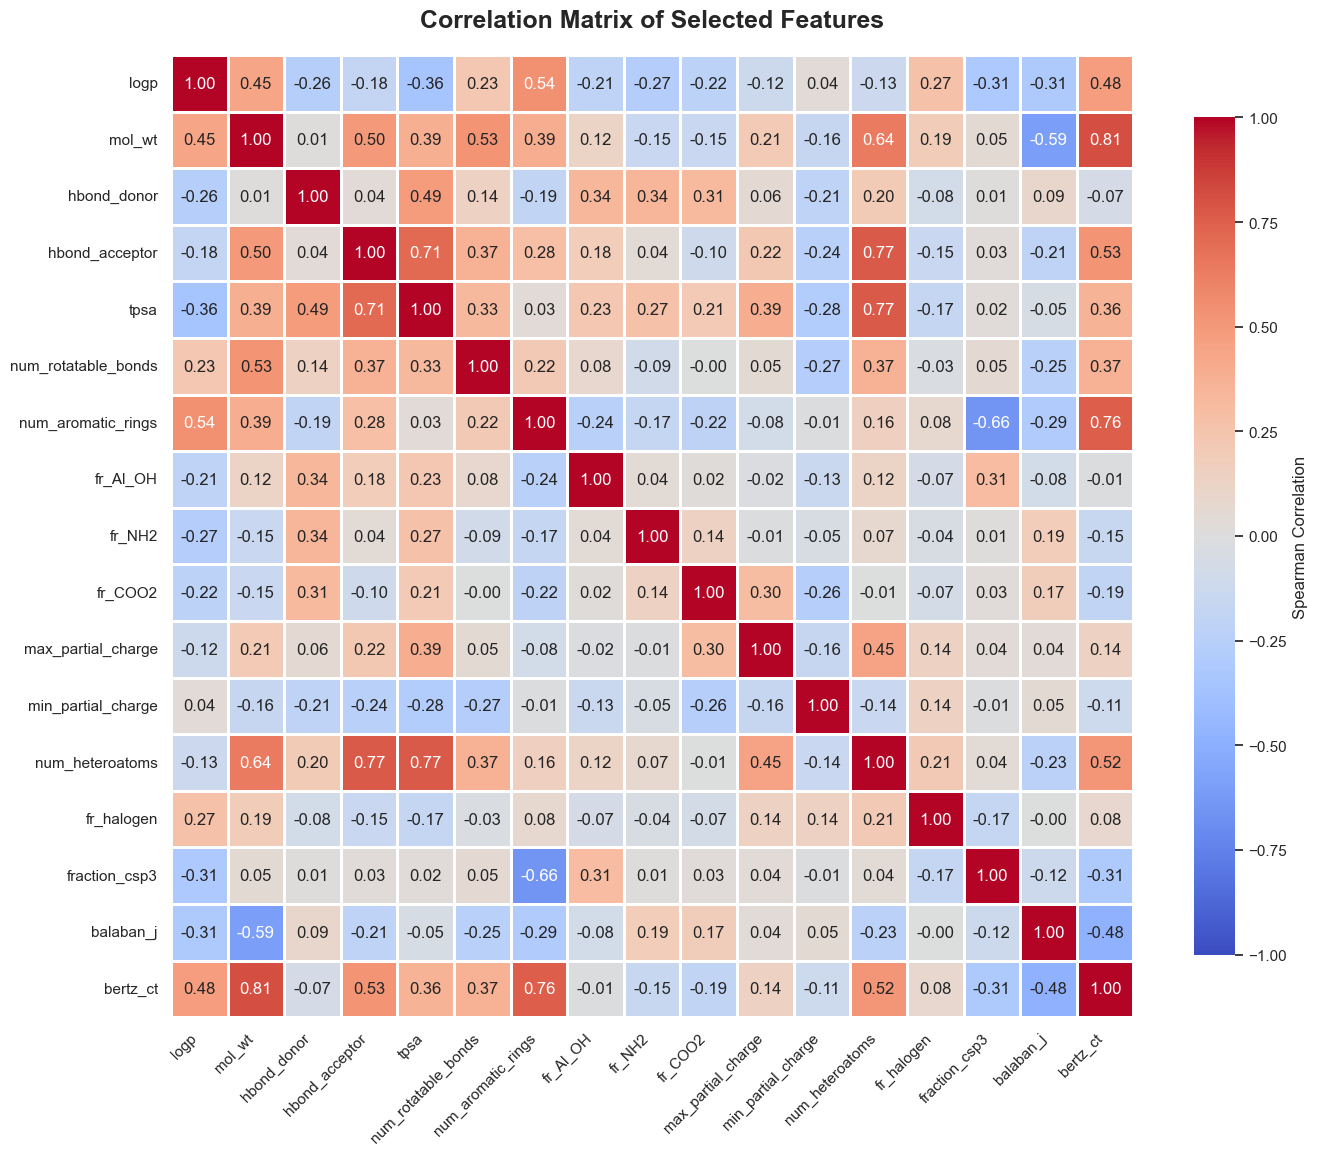

In [14]:
# Calculate the correlation matrix on the new features (X_train)
# Using Spearman correlation since the data might not be normally distributed
corr_matrix = X_train.corr(method='spearman')

sns.set_theme(style="white")
plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_matrix, 
    cmap='coolwarm',      
    vmax=1.0, vmin=-1.0,  
    center=0,
    annot=True,           
    fmt=".2f",             
    square=True,          
    linewidths=1.0,       
    cbar_kws={"shrink": .8, "label": "Spearman Correlation"}
)

plt.title('Correlation Matrix of Selected Features', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

*   Most of our engineered features are highly independent (correlation near 0), which is excellent. 
*   The only significant collinearity exists between bertz_ct (complexity) and mol_wt (size) at 0.81, and num_aromatic_rings and bertz_ct at 0.76. Chemically, larger molecules naturally possess more complex topologies and more rings. Because these remain below our strict 0.85 pruning threshold, we retain them to allow the model to differentiate between pure mass (MW) and structural branching (Bertz CT)."

A crucial sanity check is visualizing the 2D structures of our classes. This ensures RDKit parsed the SMILES strings correctly and allows us to visually inspect for obvious "chemotypes" (structural motifs) that might strictly define an inhibitor versus a non-inhibitor.

In [15]:
# Visualize Sample Molecules from Each Class

# Get 10 random inhibitors and non-inhibitors
inhibitors_sample = df_final[df_final['Y'] == 1].sample(min(10, sum(df_final['Y']==1)), random_state=42)
non_inhibitors_sample = df_final[df_final['Y'] == 0].sample(min(10, sum(df_final['Y']==0)), random_state=42)

# Parse molecules
inhibitor_mols = []
for smiles in inhibitors_sample['Drug']:
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        inhibitor_mols.append(mol)

non_inhibitor_mols = []
for smiles in non_inhibitors_sample['Drug']:
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        non_inhibitor_mols.append(mol)



=== Sample CYP2C19 Inhibitors ===


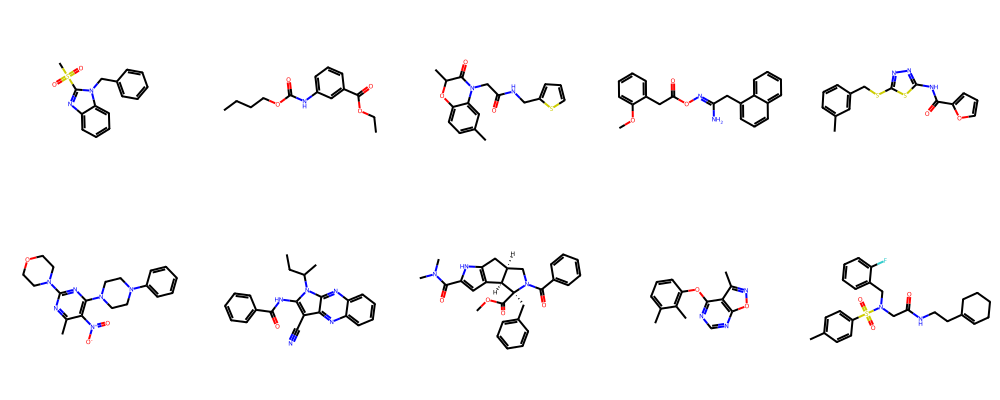


=== Sample Non-Inhibitors ===


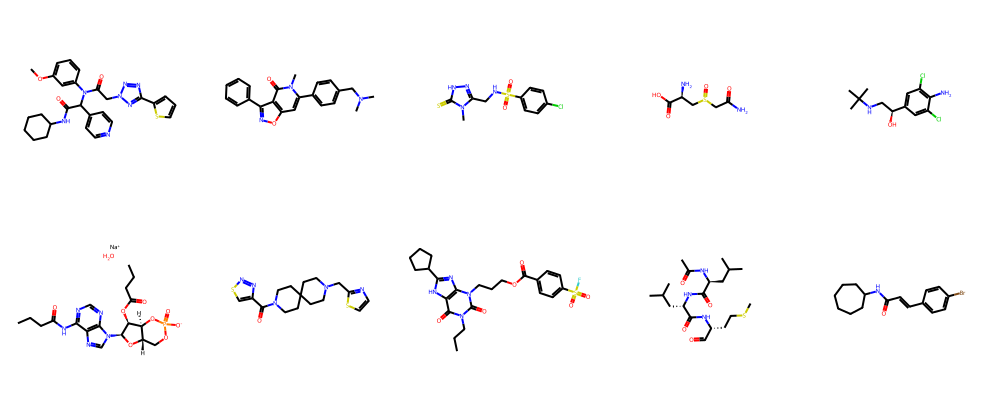

In [16]:

print("=== Sample CYP2C19 Inhibitors ===")
if inhibitor_mols:
    img = Draw.MolsToGridImage(inhibitor_mols, molsPerRow=5, subImgSize=(200, 200))
    display(img)

print("\n=== Sample Non-Inhibitors ===")
if non_inhibitor_mols:
    img = Draw.MolsToGridImage(non_inhibitor_mols, molsPerRow=5, subImgSize=(200, 200))
    display(img)

## EDA Insights:
* The dataset is relatively balanced (45.9% Inhibitors vs. 54.1% Non-Inhibitors), meaning we do not need extreme class-weighting interventions like SMOTE.
* Inhibitors tend to have slightly higher Molecular Weights and higher LogP (Lipophilicity) values compared to non-inhibitors, suggesting that larger, more fat-soluble molecules might have a higher affinity for the CYP2C19 binding pocket.

## 2. Feature Subset Experiment
To test how much information the model really needs, we compare Random Forest performance as we keep only 20%, 50%, 80%, and 100% of the descriptor set. We use supervised feature selection on the training split only, so the subset choice remains predictive rather than purely descriptive.

We use `SelectKBest(f_classif)` because it is supervised: it ranks descriptors by their association with the target label instead of by raw variance. This makes the subset experiment more meaningful for prediction and avoids keeping large-but-uninformative features.

In [17]:
#======================================================================
# Random Forest: feature subset experiment
#
# Use supervised feature selection instead of raw variance ranking.
# We impute missing values first, then apply Mutual Information on the training split only
# to properly capture non-linear relationships for the Random Forest model.
#======================================================================
from sklearn.feature_selection import mutual_info_classif

feature_percentages = [20, 50, 80, 100]
results_summary = []

selector_imputer = SimpleImputer(strategy='median')

X_train_sel_base = pd.DataFrame(
    selector_imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_valid_sel_base = pd.DataFrame(
    selector_imputer.transform(X_valid),
    columns=X_valid.columns,
    index=X_valid.index
)

X_test_sel_base = pd.DataFrame(
    selector_imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("="*70)
print("Random Forest Feature Subset Performance Analysis")
print("="*70)

for pct in feature_percentages:
    # Select the top-scoring features according to Mutual Information
    n_features = max(1, int(len(X_train_sel_base.columns) * pct / 100))
    selector = SelectKBest(score_func=mutual_info_classif, k=n_features)
    
    selector.fit(X_train_sel_base, y_train)
    selected_features = X_train_sel_base.columns[selector.get_support()].tolist()
    
    X_train_subset = X_train_sel_base[selected_features]
    X_valid_subset = X_valid_sel_base[selected_features]
    X_test_subset = X_test_sel_base[selected_features]
    
    print(f"\n[{pct}% features] Training with {n_features}/{len(X_train_sel_base.columns)} features...")
    
    # Conservative hyperparameters reduce overfitting on small feature sets
    rf_model_subset = RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=15,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    
    rf_model_subset.fit(X_train_subset, y_train)
    
    y_pred_train = rf_model_subset.predict(X_train_subset)
    y_pred_valid = rf_model_subset.predict(X_valid_subset)
    y_pred_test = rf_model_subset.predict(X_test_subset)
    
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_valid = accuracy_score(y_valid, y_pred_valid)
    acc_test = accuracy_score(y_test, y_pred_test)
    
    y_prob_train = rf_model_subset.predict_proba(X_train_subset)[:, 1]
    y_prob_valid = rf_model_subset.predict_proba(X_valid_subset)[:, 1]
    y_prob_test = rf_model_subset.predict_proba(X_test_subset)[:, 1]
    
    auc_train = roc_auc_score(y_train, y_prob_train)
    auc_valid = roc_auc_score(y_valid, y_prob_valid)
    auc_test = roc_auc_score(y_test, y_prob_test)
    
    results_summary.append({
        'Features %': pct,
        'N Features': n_features,
        'Train Acc': acc_train,
        'Valid Acc': acc_valid,
        'Test Acc': acc_test,
        'Train AUC': auc_train,
        'Valid AUC': auc_valid,
        'Test AUC': auc_test,
    })
    
    print(f" Train Acc: {acc_train:.4f} | Valid Acc: {acc_valid:.4f} | Test Acc: {acc_test:.4f}")
    print(f" Train AUC: {auc_train:.4f} | Valid AUC: {auc_valid:.4f} | Test AUC: {auc_test:.4f}")

    if pct == 100:
        rf_model = rf_model_subset
        cm_train = confusion_matrix(y_train, y_pred_train)
        cm_valid = confusion_matrix(y_valid, y_pred_valid)
        cm_test = confusion_matrix(y_test, y_pred_test)
        
        acc_train_100 = acc_train
        acc_valid_100 = acc_valid
        acc_test_100 = acc_test

# Results table
results_df_subset = pd.DataFrame(results_summary)
print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)
print(results_df_subset.to_string(index=False))

Random Forest Feature Subset Performance Analysis

[20% features] Training with 3/17 features...
 Train Acc: 0.7281 | Valid Acc: 0.6730 | Test Acc: 0.6861
 Train AUC: 0.8133 | Valid AUC: 0.7501 | Test AUC: 0.7472

[50% features] Training with 8/17 features...
 Train Acc: 0.7848 | Valid Acc: 0.7417 | Test Acc: 0.7319
 Train AUC: 0.8720 | Valid AUC: 0.8257 | Test AUC: 0.8137

[80% features] Training with 13/17 features...
 Train Acc: 0.7893 | Valid Acc: 0.7583 | Test Acc: 0.7442
 Train AUC: 0.8813 | Valid AUC: 0.8383 | Test AUC: 0.8308

[100% features] Training with 17/17 features...
 Train Acc: 0.7971 | Valid Acc: 0.7630 | Test Acc: 0.7517
 Train AUC: 0.8845 | Valid AUC: 0.8423 | Test AUC: 0.8339

SUMMARY TABLE
 Features %  N Features  Train Acc  Valid Acc  Test Acc  Train AUC  Valid AUC  Test AUC
         20           3   0.728062   0.672986  0.686143   0.813270   0.750150  0.747156
         50           8   0.784796   0.741706  0.731938   0.871966   0.825716  0.813740
         80     

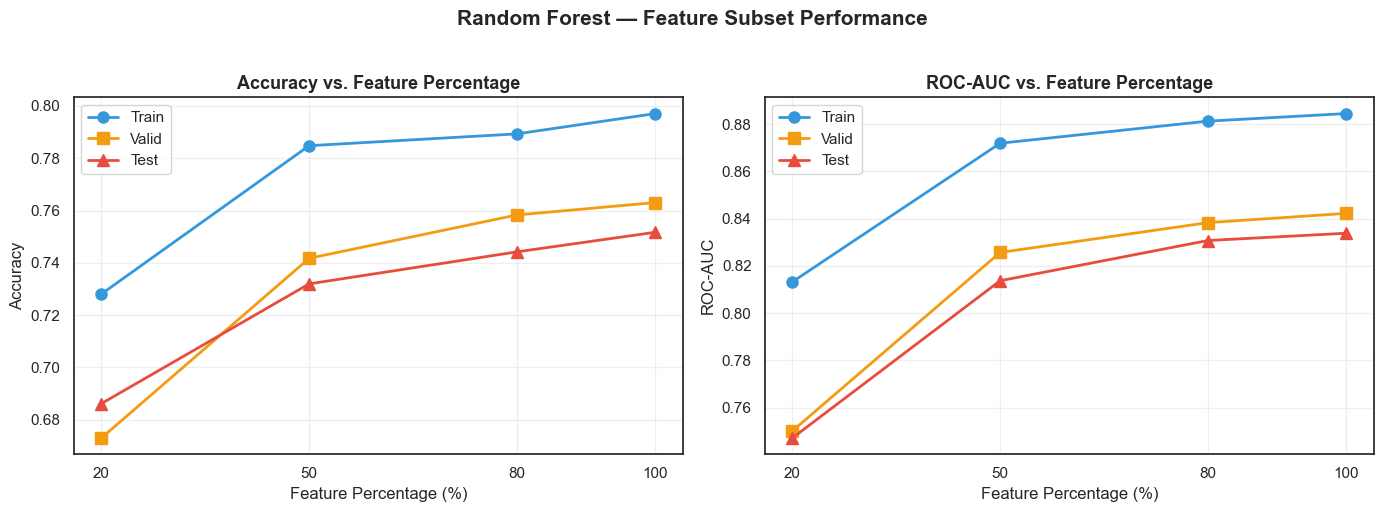

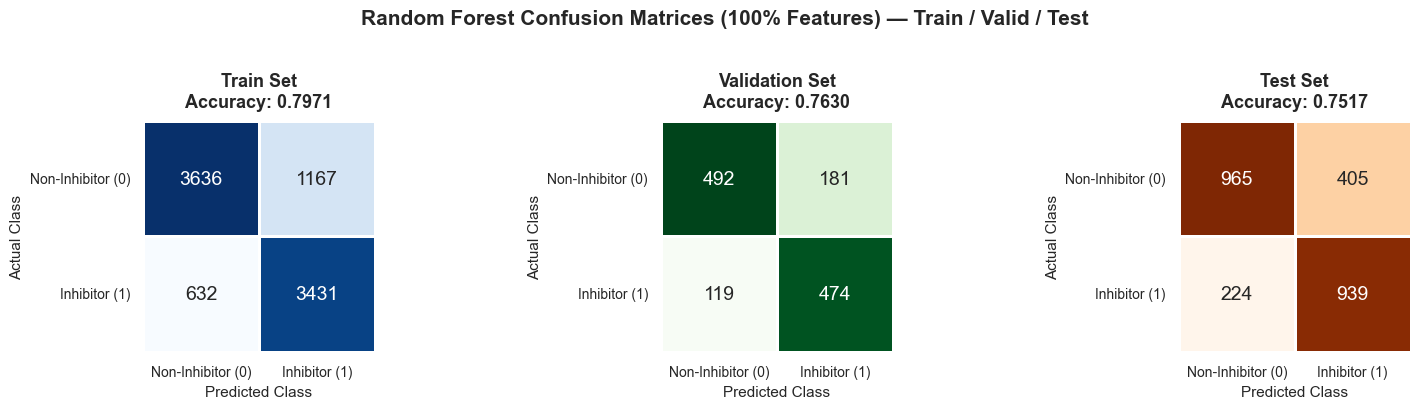


=== Accuracy Summary (100% Features) ===
Train Accuracy: 0.7971
Valid Accuracy: 0.7630
Test Accuracy:  0.7517


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df_subset['Features %'], results_df_subset['Train Acc'], 
             marker='o', linewidth=2, markersize=8, label='Train', color='#3498db')
axes[0].plot(results_df_subset['Features %'], results_df_subset['Valid Acc'], 
             marker='s', linewidth=2, markersize=8, label='Valid', color='#f39c12')
axes[0].plot(results_df_subset['Features %'], results_df_subset['Test Acc'], 
             marker='^', linewidth=2, markersize=8, label='Test', color='#e74c3c')
axes[0].set_xlabel('Feature Percentage (%)', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy vs. Feature Percentage', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].set_xticks(feature_percentages)

axes[1].plot(results_df_subset['Features %'], results_df_subset['Train AUC'], 
             marker='o', linewidth=2, markersize=8, label='Train', color='#3498db')
axes[1].plot(results_df_subset['Features %'], results_df_subset['Valid AUC'], 
             marker='s', linewidth=2, markersize=8, label='Valid', color='#f39c12')
axes[1].plot(results_df_subset['Features %'], results_df_subset['Test AUC'], 
             marker='^', linewidth=2, markersize=8, label='Test', color='#e74c3c')
axes[1].set_xlabel('Feature Percentage (%)', fontsize=12)
axes[1].set_ylabel('ROC-AUC', fontsize=12)
axes[1].set_title('ROC-AUC vs. Feature Percentage', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_xticks(feature_percentages)

fig.suptitle('Random Forest — Feature Subset Performance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar=False, square=True, linewidths=2, annot_kws={"size": 14})
axes[0].set_title(f'Train Set\nAccuracy: {acc_train_100:.4f}', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Class', fontsize=11)
axes[0].set_ylabel('Actual Class', fontsize=11)
axes[0].set_xticklabels(['Non-Inhibitor (0)', 'Inhibitor (1)'], fontsize=10)
axes[0].set_yticklabels(['Non-Inhibitor (0)', 'Inhibitor (1)'], fontsize=10, rotation=0)

sns.heatmap(cm_valid, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            cbar=False, square=True, linewidths=2, annot_kws={"size": 14})
axes[1].set_title(f'Validation Set\nAccuracy: {acc_valid_100:.4f}', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Predicted Class', fontsize=11)
axes[1].set_ylabel('Actual Class', fontsize=11)
axes[1].set_xticklabels(['Non-Inhibitor (0)', 'Inhibitor (1)'], fontsize=10)
axes[1].set_yticklabels(['Non-Inhibitor (0)', 'Inhibitor (1)'], fontsize=10, rotation=0)

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            cbar=False, square=True, linewidths=2, annot_kws={"size": 14})
axes[2].set_title(f'Test Set\nAccuracy: {acc_test_100:.4f}', fontsize=13, fontweight='bold', pad=10)
axes[2].set_xlabel('Predicted Class', fontsize=11)
axes[2].set_ylabel('Actual Class', fontsize=11)
axes[2].set_xticklabels(['Non-Inhibitor (0)', 'Inhibitor (1)'], fontsize=10)
axes[2].set_yticklabels(['Non-Inhibitor (0)', 'Inhibitor (1)'], fontsize=10, rotation=0)

fig.suptitle('Random Forest Confusion Matrices (100% Features) — Train / Valid / Test', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n=== Accuracy Summary (100% Features) ===")
print(f"Train Accuracy: {acc_train_100:.4f}")
print(f"Valid Accuracy: {acc_valid_100:.4f}")
print(f"Test Accuracy:  {acc_test_100:.4f}")

*   **Performance Scaling:** Both Accuracy and ROC-AUC climb steadily as we increase the feature percentage. 
*   **Optimal Subset:** The highest Test AUC (0.839) is achieved using 100% of the features. Every single one of the 17 descriptors contributes meaningful, non-redundant variance to the model's predictive power.

Tree-based models naturally calculate "Gini Importance" during training, which tells us how often a feature was used to split the data and how much it reduced impurity.

In [19]:
# 1. Extract feature importances and names from the trained Random Forest
importances = rf_model.feature_importances_
feature_names = X_train.columns

# 2. Create a Pandas DataFrame to hold and sort the data
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 3. Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)



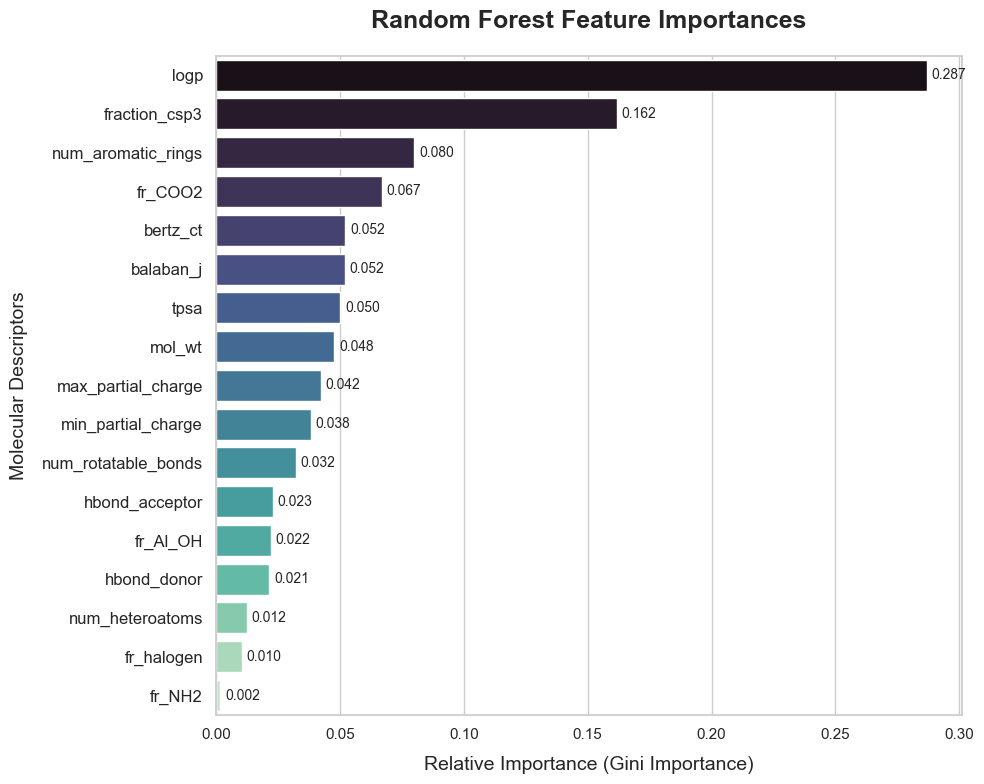

In [20]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))


sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df, 
    palette='mako'
)


plt.title('Random Forest Feature Importances', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Relative Importance (Gini Importance)', fontsize=14, labelpad=10)
plt.ylabel('Molecular Descriptors', fontsize=14, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=12)

# exact values at the end of each bar for clarity
for index, value in enumerate(importance_df['Importance']):
    plt.text(value + 0.002, index, f'{value:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

The Gini importance plot reveals a steep drop-off. CYP2C19 inhibition is overwhelmingly governed by just two factors: lipophilicity (logp) and 3D spatial bulk (fraction_csp3), which together account for nearly 45% of the model's decision weight. The remaining 15 features act as fine-tuning parameters. Interestingly, specific functional groups like halogens and amines (fr_halogen, fr_NH2) offer almost no global predictive value on their own, likely because their influence is already captured by the broader electronic and shape descriptors.

## 3. Model Implementation & Comparison
We compare four distinct algorithms (Logistic Regression, Random Forest, XGBoost, Support Vector Machines) across three feature representations:
1. **Descriptors (17D):** Curated physicochemical properties, including 3D shape proxies and halogen counts.
2. **Morgan FP (1024D):** ECFP4 structural fingerprints capturing molecular substructures.
3. **Combined (1041D):** Concatenation of both.

Why this design:
- **Multiple models** test linear vs. non-linear decision boundaries.
- **Multiple feature sets** reveal whether handcrafted descriptors or fingerprints carry more predictive signal.
- **Pipelines** keep preprocessing and modeling coupled to prevent data leakage.

### Unified Evaluation Metrics
Relying solely on Accuracy is dangerous in chemical classification. We define a custom evaluation function to track multiple metrics across our models:
*   **ROC-AUC:** Measures the model's ability to rank inhibitors higher than non-inhibitors across all threshold values.
*   **PR-AUC (Average Precision):** Crucial for evaluating performance on the minority/positive class.
*   **F1, Precision, and Recall:** To understand the trade-off between false positives (wasted lab resources) and false negatives (missed drug liabilities).

In [21]:
# =============================================================================
# CYP2C19 — Pipeline Extension
# =============================================================================
# =============================================================================
# UNIFIED EVALUATION FUNCTION
# =============================================================================

def _sigmoid(x):
    return 1 / (1 + np.exp(-x))

def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        y_prob = y_score
    else:
        y_score = model.decision_function(X_test)
        y_prob = _sigmoid(y_score)
    return {
        "Model"    : model_name,
        "AUROC"    : round(roc_auc_score(y_test, y_score), 4),
        "PR-AUC"   : round(average_precision_score(y_test, y_prob), 4),
        "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "F1"       : round(f1_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall"   : round(recall_score(y_test, y_pred), 4),
        "_y_prob"  : y_prob,
    }




In [22]:
# =============================================================================
# FEATURE SETS & MODEL DEFINITIONS
# =============================================================================

y_train_arr = y_train.values
y_valid_arr = y_valid.values
y_test_arr  = y_test.values

feature_sets = {
    "Descriptors": (X_train,           X_valid,           X_test),
    "Morgan FP"  : (train_fp_df,        valid_fp_df,        test_fp_df),
    "Combined"   : (X_train_benchmark,  X_valid_benchmark,  X_test_benchmark),
}




### Hyperparameter Tuning with Cross-Validation
Before comparing models, we tune hyperparameters separately for each feature representation using **k-fold cross-validation on the training split** and then report validation metrics as a secondary check. This keeps the test set untouched until the very end, so the final metrics remain honest.

Crucially, descriptors, Morgan fingerprints, and combined features each receive their own tuned parameter set instead of sharing a single descriptor-optimized configuration.

=== Feature-Set-Specific Hyperparameter Tuning (Randomized Search) ===

[Descriptors]
  -> Tuning Logistic Regression (Testing 5 of 5 combinations)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
  -> Tuning Random Forest (Testing 15 of 36 combinations)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
  -> Tuning XGBoost (Testing 15 of 216 combinations)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
  [+] Descriptors best parameters found:
      - Logistic Regression: {'C': 10.0}
      - Random Forest: {'n_estimators': 400, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 12}
      - XGBoost: {'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 10, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

[Morgan FP]
  -> Tuning Logistic Regression (Testing 5 of 5 combinations)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
  -> Tuning Random Forest (Testing 15 of 36 combinations)...
Fitting 3 folds

,Feature Set,Model,Params,CV AUROC,Val AUROC,Val PR-AUC,Val Acc,Val F1
0,Descriptors,XGBoost,"{'clf__subsample': 0.8, 'clf__n_estimators': 4...",0.8663,0.8688,0.8309,0.7962,0.7814
1,Descriptors,Random Forest,"{'clf__n_estimators': 400, 'clf__min_samples_l...",0.8622,0.8619,0.8243,0.7867,0.7754
2,Descriptors,Logistic Regression,{'clf__C': 10.0},0.8017,0.7975,0.7397,0.7385,0.7320
3,Morgan FP,XGBoost,"{'clf__subsample': 0.8, 'clf__n_estimators': 4...",0.8698,0.8813,0.8478,0.7954,0.7840
4,Morgan FP,Logistic Regression,{'clf__C': 0.01},0.8453,0.8564,0.8082,0.7725,0.7559
5,Morgan FP,Random Forest,"{'clf__n_estimators': 400, 'clf__min_samples_l...",0.8363,0.8478,0.8105,0.7528,0.7157
6,Combined,XGBoost,"{'clf__subsample': 0.8, 'clf__n_estimators': 2...",0.8946,0.8980,0.8636,0.8278,0.8201
7,Combined,Random Forest,"{'clf__n_estimators': 200, 'clf__min_samples_l...",0.8650,0.8712,0.8384,0.7899,0.7802
8,Combined,Logistic Regression,{'clf__C': 0.01},0.8573,0.8629,0.8145,0.7836,0.7694



Best classifier parameters selected for the downstream comparison:
- Descriptors: {'Logistic Regression': {'C': 10.0}, 'Random Forest': {'n_estimators': 400, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 12}, 'XGBoost': {'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 10, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}}
- Morgan FP: {'Logistic Regression': {'C': 0.01}, 'Random Forest': {'n_estimators': 400, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 12}, 'XGBoost': {'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 10, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}}
- Combined: {'Logistic Regression': {'C': 0.01}, 'Random Forest': {'n_estimators': 200, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 12}, 'XGBoost': {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}}


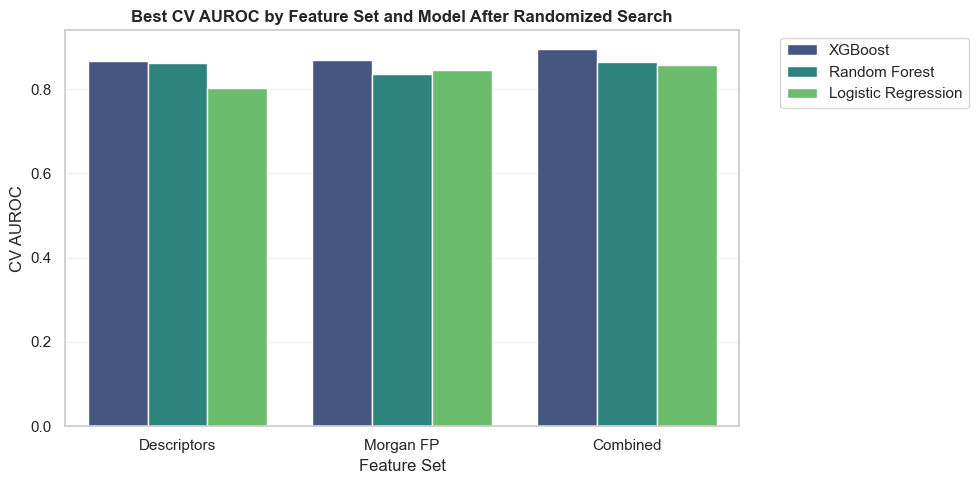

In [24]:
DEFAULT_CLASSIFIER_PARAMS = {
    "Logistic Regression": {"C": 1.0},
    "Random Forest": {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 2},
    "XGBoost": {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 6},
    "SVM (RBF)": {"C": 1.0, "gamma": "scale"},
}

PARAM_GRIDS = {
    "Logistic Regression": {"clf__C": [0.01, 0.1, 1.0, 3.0, 10.0]}, 
    "Random Forest": {
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [4, 8, 12], 
        "clf__min_samples_leaf": [4, 10, 20], 
        "clf__max_features": ["sqrt", "log2"]
    },
    "XGBoost": {
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [3, 5, 7], 
        "clf__learning_rate": [0.01, 0.05, 0.1],
        "clf__min_child_weight": [5, 10, 20], 
        "clf__subsample": [0.7, 0.8],
        "clf__colsample_bytree": [0.7, 0.8],
    }
}


def _tuning_pipeline(model_name):
    if model_name == "Logistic Regression":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, solver="lbfgs", random_state=42)),
        ])
    if model_name == "Random Forest":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(random_state=42, n_jobs=-1)),
        ])
    if model_name == "XGBoost":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0)),
        ])
    if model_name == "SVM (RBF)":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", probability=True, random_state=42)),
        ])
    raise ValueError(f"Unknown model: {model_name}")


def _clean_classifier_params(model_name, classifier_params):
    params = classifier_params.get(model_name, DEFAULT_CLASSIFIER_PARAMS[model_name])
    return {k.replace("clf__", ""): v for k, v in params.items()}

from sklearn.model_selection import RandomizedSearchCV, ParameterGrid, StratifiedKFold
import time

def tune_classifier_params(X_tr, X_va, y_tr, y_va, feature_set_name, n_splits=3, n_iter=15):
    """
    Smarter, faster tuning using Randomized Search and NumPy arrays to bypass Pandas overhead.
    n_splits: Reduced to 3 to save time.
    n_iter: Maximum number of parameter combinations to try per model.
    """
    tuning_rows = []
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # 1. Strip Pandas overhead for much faster multiprocessing serialization
    X_tr_np = X_tr.to_numpy(dtype=np.float32) if hasattr(X_tr, 'to_numpy') else X_tr
    y_tr_np = y_tr.to_numpy() if hasattr(y_tr, 'to_numpy') else y_tr
    X_va_np = X_va.to_numpy(dtype=np.float32) if hasattr(X_va, 'to_numpy') else X_va

    best_params_dict = {}

    for model_name, grid in PARAM_GRIDS.items():
        base_pipe = _tuning_pipeline(model_name)
        
        # Prevent errors if a grid has fewer total combinations than n_iter
        max_combos = len(list(ParameterGrid(grid)))
        current_n_iter = min(n_iter, max_combos)

        print(f"  -> Tuning {model_name} (Testing {current_n_iter} of {max_combos} combinations)...")

        # 2. THE SMART TUNER: RandomizedSearchCV handles the CV loop automatically
        search = RandomizedSearchCV(
            estimator=base_pipe,
            param_distributions=grid,
            n_iter=current_n_iter,
            scoring="roc_auc",
            cv=cv,
            n_jobs=-1,          # Use all available CPU cores
            random_state=42,    # Keep it reproducible
            verbose=1
        )
        
        # Run the automated CV search
        search.fit(X_tr_np, y_tr_np)
        
        # 3. Extract the best model from the search
        best_model = search.best_estimator_
        best_params = search.best_params_
        cv_mean = search.best_score_
        
        # Evaluate the winning model on the untouched Validation split
        val_pred = best_model.predict(X_va_np)
        if hasattr(best_model, "predict_proba"):
            val_prob = best_model.predict_proba(X_va_np)[:, 1]
        else:
            val_prob = best_model.decision_function(X_va_np)
            
        # Log the results
        tuning_rows.append({
            "Feature Set": feature_set_name,
            "Model": model_name,
            "Params": best_params,
            "CV AUROC": round(cv_mean, 4),
            "Val AUROC": round(roc_auc_score(y_va, val_prob), 4),
            "Val PR-AUC": round(average_precision_score(y_va, val_prob), 4),
            "Val Acc": round(accuracy_score(y_va, val_pred), 4),
            "Val F1": round(f1_score(y_va, val_pred), 4),
        })
        
        # Clean the "clf__" prefix off the winning parameters for downstream use
        best_params_dict[model_name] = {k.replace("clf__", ""): v for k, v in best_params.items()}

    # Format the output tables
    tuning_df = pd.DataFrame(tuning_rows).sort_values("CV AUROC", ascending=False).reset_index(drop=True)
    return tuning_df, best_params_dict

# ==========================================
# EXECUTION LOOP & VISUALIZATION
# ==========================================

BEST_CLASSIFIER_PARAMS_BY_FEATURE_SET = {}
tuning_tables = []

print("=== Feature-Set-Specific Hyperparameter Tuning (Randomized Search) ===")
t0 = time.time()

for feat_name, (X_tr_feat, X_va_feat, _) in feature_sets.items():
    print(f"\n[{feat_name}]")
    tuning_df_feat, best_params_feat = tune_classifier_params(
        X_tr_feat, X_va_feat, y_train_arr, y_valid_arr, feat_name, n_splits=3, n_iter=15
    )
    
    BEST_CLASSIFIER_PARAMS_BY_FEATURE_SET[feat_name] = best_params_feat
    tuning_tables.append(tuning_df_feat)

    print(f"  [+] {feat_name} best parameters found:")
    for model_name, params in best_params_feat.items():
        print(f"      - {model_name}: {params}")

print(f"\nTotal Tuning Time: {(time.time() - t0)/60:.1f} minutes")

# Combine all results into one table
tuning_df = pd.concat(tuning_tables, ignore_index=True)

print("\n=== Validation-Based Hyperparameter Tuning ===")
display(tuning_df[["Feature Set", "Model", "Params", "CV AUROC", "Val AUROC", "Val PR-AUC", "Val Acc", "Val F1"]])

print("\nBest classifier parameters selected for the downstream comparison:")
for feat_name, params_by_model in BEST_CLASSIFIER_PARAMS_BY_FEATURE_SET.items():
    print(f"- {feat_name}: {params_by_model}")

# Plotting the results
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=tuning_df, x="Feature Set", y="CV AUROC", hue="Model", palette="viridis", ax=ax)
ax.set_title("Best CV AUROC by Feature Set and Model After Randomized Search", fontweight="bold")
ax.set_ylabel("CV AUROC")
ax.set_xlabel("Feature Set")
ax.grid(axis="y", alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [25]:
def _feature_preprocessor(feature_set_name):
    """Build preprocessing that respects the data type of each feature set."""
    descriptor_cols = list(X_train.columns)
    fingerprint_cols = list(train_fp_df.columns)

    if feature_set_name == "Descriptors":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ])

    if feature_set_name == "Morgan FP":
        # Morgan fingerprints are binary/sparse-like; do not center or scale them.
        return Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
        ])

    if feature_set_name == "Combined":
        # Scale descriptors only; pass fingerprint bits through unchanged.
        return ColumnTransformer([
            ("desc", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), descriptor_cols),
            ("fp", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
            ]), fingerprint_cols),
        ], remainder="drop")

    raise ValueError(f"Unknown feature set: {feature_set_name}")


def make_models(feature_set_name="Descriptors", classifier_params=None):
    classifier_params = classifier_params or BEST_CLASSIFIER_PARAMS_BY_FEATURE_SET.get(
        "Descriptors", DEFAULT_CLASSIFIER_PARAMS
    )
    preprocessor = _feature_preprocessor(feature_set_name)

    # The preprocessing step is feature-set aware: fingerprints are not standardized,
    # while descriptors are scaled only when that is statistically appropriate.
    return {
        "Logistic Regression": Pipeline([
            ("preprocess", preprocessor),
            ("clf", LogisticRegression(max_iter=2000, solver="lbfgs", random_state=42, **_clean_classifier_params("Logistic Regression", classifier_params))),
        ]),
        "Random Forest": Pipeline([
            ("preprocess", preprocessor),
            ("clf", RandomForestClassifier(random_state=42, n_jobs=-1, **_clean_classifier_params("Random Forest", classifier_params))),
        ]),
        "XGBoost": Pipeline([
            ("preprocess", preprocessor),
            ("clf", XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0, **_clean_classifier_params("XGBoost", classifier_params))),
        ]),
        "SVM (RBF)": Pipeline([
            ("preprocess", preprocessor),
            ("clf", SVC(kernel="rbf", probability=True, random_state=42, **_clean_classifier_params("SVM (RBF)", classifier_params))),
        ]),
    }

In [26]:
# =============================================================================
# TRAINING LOOP
# =============================================================================

all_results    = []
trained_models = {}

for feat_name, (X_tr, X_va, X_te) in feature_sets.items():
    print(f"\n{'='*75}\nFeature set: {feat_name}  ({X_tr.shape[1]} features)\n{'='*75}")
    classifier_params = BEST_CLASSIFIER_PARAMS_BY_FEATURE_SET[feat_name]
    for model_name, model in make_models(feature_set_name=feat_name, classifier_params=classifier_params).items():
        t0 = time.time()
        
        # Fit on training split for Train/Valid diagnostics
        model.fit(X_tr, y_train_arr)
        
        train_m = evaluate_model(model, X_tr, y_train_arr, model_name)
        val_m   = evaluate_model(model, X_va, y_valid_arr, model_name)
        
        # Refit on Train+Valid for final test evaluation
        X_tr_full = pd.concat([X_tr, X_va], axis=0)
        y_tr_full = np.concatenate([y_train_arr, y_valid_arr])
        model.fit(X_tr_full, y_tr_full)
        test_m  = evaluate_model(model, X_te, y_test_arr,  model_name)
        
        trained_models[(feat_name, model_name)] = model
        
        all_results.append({
            "Feature Set"  : feat_name,
            "Model"        : model_name,
            "Train Acc"    : train_m["Accuracy"], 
            "Val Acc"      : val_m["Accuracy"],   
            "Val AUROC"    : val_m["AUROC"],
            "Test AUROC"   : test_m["AUROC"],
            "Test PR-AUC"  : test_m["PR-AUC"],
            "Test Acc"     : test_m["Accuracy"],
            "Test F1"      : test_m["F1"],
            "Test Prec"    : test_m["Precision"],
            "Test Rec"     : test_m["Recall"],
            "_y_prob"      : test_m["_y_prob"],
        })
        
        print(f"  {model_name:22s} | Train Acc={train_m['Accuracy']:.4f} "
              f"| Val Acc={val_m['Accuracy']:.4f} "
              f"| Test Acc={test_m['Accuracy']:.4f} "
              f"| Test AUROC={test_m['AUROC']:.4f} | {time.time()-t0:.1f}s")

results_df = pd.DataFrame(all_results).drop(columns=["_y_prob"])




Feature set: Descriptors  (17 features)
  Logistic Regression    | Train Acc=0.7361 | Val Acc=0.7385 | Test Acc=0.7043 | Test AUROC=0.7785 | 0.1s
  Random Forest          | Train Acc=0.8666 | Val Acc=0.7828 | Test Acc=0.7817 | Test AUROC=0.8565 | 1.3s
  XGBoost                | Train Acc=0.8948 | Val Acc=0.7954 | Test Acc=0.7896 | Test AUROC=0.8635 | 1.2s
  SVM (RBF)              | Train Acc=0.8062 | Val Acc=0.7891 | Test Acc=0.7710 | Test AUROC=0.8440 | 9.9s

Feature set: Morgan FP  (1024 features)
  Logistic Regression    | Train Acc=0.7993 | Val Acc=0.7820 | Test Acc=0.7848 | Test AUROC=0.8598 | 0.9s
  Random Forest          | Train Acc=0.8071 | Val Acc=0.7528 | Test Acc=0.7564 | Test AUROC=0.8396 | 1.6s
  XGBoost                | Train Acc=0.8700 | Val Acc=0.7954 | Test Acc=0.8042 | Test AUROC=0.8784 | 2.9s
  SVM (RBF)              | Train Acc=0.9147 | Val Acc=0.8152 | Test Acc=0.8176 | Test AUROC=0.8870 | 386.8s

Feature set: Combined  (1041 features)
  Logistic Regression    | T

### 3.1 Dimensionality Reduction & Robustness Checks
High-dimensional representations (especially 1024-bit fingerprints) can make linear models unstable and increase overfitting risk. We therefore test a reduced-feature variant to answer two questions:
1. **Does performance remain stable when we compress the inputs?** If yes, the signal is robust.
2. **Does any model improve when noise is reduced?** This can reveal overfitting in the full space.

We reduce each representation in a way that preserves its structure:
- **Descriptors:** Standardize then use KMeans distance features (captures prototype-like clusters).
- **Morgan FP:** TruncatedSVD to compress sparse binary fingerprints efficiently.
- **Combined:** PCA on descriptors + TruncatedSVD on fingerprints, then concatenate. This avoids mixing incompatible feature types before reduction.

In [27]:
# =============================================================================
# MODEL DEFINITION 
# =============================================================================

def make_models(feature_set_name, n_clusters=35, fp_components=256, skip_reduction=False, classifier_params=None):
    """
    Creates ML models wrapped in a Pipeline.
    The Pipeline replaces original features with lower-dimensional representations.
    Descriptors: StandardScaler + KMeans (cluster distances).
    Morgan FP: TruncatedSVD on sparse fingerprints.
    Combined: PCA on descriptors + TruncatedSVD on fingerprints, then concatenate.
    """
    from sklearn.decomposition import TruncatedSVD, PCA
    
    classifier_params = classifier_params or BEST_CLASSIFIER_PARAMS_BY_FEATURE_SET.get(
        "Descriptors", DEFAULT_CLASSIFIER_PARAMS
    )
    
    descriptor_cols = list(X_train.columns)
    fingerprint_cols = list(train_fp_df.columns)
    
    def _new_kmeans():
        return KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        
    def _new_svd():
        return TruncatedSVD(n_components=fp_components, random_state=42)
        
    def _build_models(preprocess):
        return {
            "Logistic Regression": Pipeline([
                ("preprocess", preprocess),
                ("clf", LogisticRegression(max_iter=2000, solver="lbfgs", random_state=42, **_clean_classifier_params("Logistic Regression", classifier_params)))
            ]),
            "Random Forest": Pipeline([
                ("preprocess", preprocess),
                ("clf", RandomForestClassifier(random_state=42, n_jobs=-1, **_clean_classifier_params("Random Forest", classifier_params)))
            ]),
            "XGBoost": Pipeline([
                ("preprocess", preprocess),
                ("clf", XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0, **_clean_classifier_params("XGBoost", classifier_params)))
            ]),
            "SVM (RBF)": Pipeline([
                ("preprocess", preprocess),
                ("clf", SVC(kernel="rbf", probability=True, random_state=42, **_clean_classifier_params("SVM (RBF)", classifier_params)))
            ])
        }

    if skip_reduction:
        if feature_set_name == "Morgan FP":
            preprocess = Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
            ])
        elif feature_set_name == "Descriptors":
            preprocess = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ])
        elif feature_set_name == "Combined":
            preprocess = ColumnTransformer([
                ("desc", Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]), descriptor_cols),
                ("fp", Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                ]), fingerprint_cols),
            ], remainder="drop")
        else:
            raise ValueError(f"Unknown feature set: {feature_set_name}")
            
        return _build_models(preprocess)

    # Apply Dimensionality Reduction
    if feature_set_name == "Morgan FP":
        preprocess = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("svd", _new_svd()),
        ])
        return _build_models(preprocess)
        
    if feature_set_name == "Descriptors":
        preprocess = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("kmeans", _new_kmeans()),
        ])
        return _build_models(preprocess)
        
    if feature_set_name == "Combined":
        desc_components = min(8, len(descriptor_cols))
        preprocess = ColumnTransformer([
            ("desc", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("pca", PCA(n_components=desc_components, random_state=42)),
            ]), descriptor_cols),
            ("fp", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("svd", _new_svd()),
            ]), fingerprint_cols),
        ], remainder="drop")
        return _build_models(preprocess)

    raise ValueError(f"Unknown feature set: {feature_set_name}")

In [28]:
# =============================================================================
# TRAINING LOOP
# =============================================================================

all_results_reduced    = []
trained_models_reduced = {}

# Dimensionality reduction targets
num_clusters = 35
fp_svd_components = 256

for feat_name, (X_tr, X_va, X_te) in feature_sets.items():
    
    # Bypass reduction if dimension is already <= target components
    if feat_name == "Morgan FP":
        skip_reduction = X_tr.shape[1] <= fp_svd_components
    elif feat_name == "Combined":
        skip_reduction = False
    else:
        skip_reduction = X_tr.shape[1] <= num_clusters
    
    print(f"\n{'='*80}")
    if skip_reduction:
        print(f"Feature set: {feat_name} | Original: {X_tr.shape[1]} dims --> Kept at {X_tr.shape[1]} dims (Bypassed Reduction)")
    else:
        if feat_name == "Morgan FP":
            print(f"Feature set: {feat_name} | Original: {X_tr.shape[1]} dims --> Compressed: {fp_svd_components} dims")
        elif feat_name == "Combined":
            print(f"Feature set: {feat_name} | Descriptor PCA: {min(num_clusters, X_train.shape[1])} dims | FP SVD: {fp_svd_components} dims")
        else:
            print(f"Feature set: {feat_name} | Original: {X_tr.shape[1]} dims --> Compressed: {num_clusters} dims")
    print(f"{'='*80}")
    
    classifier_params = BEST_CLASSIFIER_PARAMS_BY_FEATURE_SET[feat_name]
    for model_name, model in make_models(feature_set_name=feat_name, n_clusters=num_clusters, fp_components=fp_svd_components, skip_reduction=skip_reduction, classifier_params=classifier_params).items():
        t0 = time.time()
        
        # Training (Pipeline handles the reduction internally if not bypassed)
        model.fit(X_tr, y_train_arr)
        
        # Evaluation on all splits to monitor overfitting
        train_m = evaluate_model(model, X_tr, y_train_arr, model_name)
        val_m   = evaluate_model(model, X_va, y_valid_arr, model_name)
        test_m  = evaluate_model(model, X_te, y_test_arr,  model_name)
        
        trained_models_reduced[(feat_name, model_name)] = model
        
        # Store results
        all_results_reduced.append({
            "Feature Set"  : feat_name,
            "Model"        : model_name,
            "Train Acc"    : train_m["Accuracy"],
            "Val Acc"      : val_m["Accuracy"],  
            "Val AUROC"    : val_m["AUROC"],
            "Test AUROC"   : test_m["AUROC"],
            "Test PR-AUC"  : test_m["PR-AUC"],
            "Test Acc"     : test_m["Accuracy"],
            "Test F1"      : test_m["F1"],
            "Test Prec"    : test_m["Precision"],
            "Test Rec"     : test_m["Recall"],
            "_y_prob"      : test_m["_y_prob"],
        })
        
        print(f"  {model_name:22s} | Train Acc={train_m['Accuracy']:.4f} "
              f"| Val Acc={val_m['Accuracy']:.4f} "
              f"| Test Acc={test_m['Accuracy']:.4f} "
              f"| Test AUROC={test_m['AUROC']:.4f} | {time.time()-t0:.1f}s")

results_df = pd.DataFrame(all_results_reduced).drop(columns=["_y_prob"])


Feature set: Descriptors | Original: 17 dims --> Kept at 17 dims (Bypassed Reduction)
  Logistic Regression    | Train Acc=0.7361 | Val Acc=0.7385 | Test Acc=0.7035 | Test AUROC=0.7787 | 0.0s
  Random Forest          | Train Acc=0.8666 | Val Acc=0.7828 | Test Acc=0.7793 | Test AUROC=0.8550 | 0.8s
  XGBoost                | Train Acc=0.8948 | Val Acc=0.7954 | Test Acc=0.7892 | Test AUROC=0.8596 | 0.6s
  SVM (RBF)              | Train Acc=0.8062 | Val Acc=0.7891 | Test Acc=0.7742 | Test AUROC=0.8435 | 5.3s

Feature set: Morgan FP | Original: 1024 dims --> Compressed: 256 dims
  Logistic Regression    | Train Acc=0.7814 | Val Acc=0.7694 | Test Acc=0.7694 | Test AUROC=0.8495 | 1.3s
  Random Forest          | Train Acc=0.9799 | Val Acc=0.7607 | Test Acc=0.7623 | Test AUROC=0.8558 | 3.3s
  XGBoost                | Train Acc=0.9976 | Val Acc=0.7844 | Test Acc=0.7848 | Test AUROC=0.8689 | 3.8s
  SVM (RBF)              | Train Acc=0.8822 | Val Acc=0.8081 | Test Acc=0.8066 | Test AUROC=0.8781 |

In [29]:
# =============================================================================
# RESULTS TABLE
# =============================================================================

display_cols = ["Train Acc", "Val Acc", "Test Acc", "Test AUROC", "Test PR-AUC", "Test F1"]
styled = (
    results_df.style
    .highlight_max(subset=display_cols, color="#c6efce", axis=0)
    .highlight_min(subset=display_cols, color="#ffc7ce", axis=0)
    .format({c: "{:.4f}" for c in display_cols})
    .set_caption(f"Model Comparison (Reduced Representations) — CYP2C19")
)

# For Jupyter Notebook:
display(styled)

# If you are running this in a standard Python script (not Jupyter), 
# uncomment the following line to print the dataframe to the console:
# print(results_df[display_cols].to_string())

,Feature Set,Model,Train Acc,Val Acc,Val AUROC,Test AUROC,Test PR-AUC,Test Acc,Test F1,Test Prec,Test Rec
0,Descriptors,Logistic Regression,0.7361,0.7385,0.797500,0.7787,0.7177,0.7035,0.6921,0.661400,0.725700
1,Descriptors,Random Forest,0.8666,0.7828,0.862100,0.8550,0.8225,0.7793,0.7678,0.742800,0.794500
2,Descriptors,XGBoost,0.8948,0.7954,0.868400,0.8596,0.8261,0.7892,0.7733,0.763600,0.783300
3,Descriptors,SVM (RBF),0.8062,0.7891,0.856000,0.8435,0.7989,0.7742,0.7582,0.745600,0.771300
4,Morgan FP,Logistic Regression,0.7814,0.7694,0.848100,0.8495,0.8055,0.7694,0.7491,0.748500,0.749800
5,Morgan FP,Random Forest,0.9799,0.7607,0.854800,0.8558,0.8173,0.7623,0.7195,0.785400,0.663800
6,Morgan FP,XGBoost,0.9976,0.7844,0.874000,0.8689,0.8361,0.7848,0.7694,0.757500,0.781600
7,Morgan FP,SVM (RBF),0.8822,0.8081,0.881500,0.8781,0.8418,0.8066,0.7938,0.777400,0.810800
8,Combined,Logistic Regression,0.8006,0.7828,0.862100,0.8594,0.8144,0.7923,0.7795,0.760400,0.799700
9,Combined,Random Forest,0.9253,0.7749,0.862800,0.8606,0.8275,0.7837,0.7688,0.754800,0.783300


**Reduced-space takeaways:**
- This check tells us whether the models rely on a few stable factors or on very high-dimensional noise.
- If performance holds up after compression, the representation is robust; if it drops sharply, the original space is likely carrying fragile signal.

## 4. Model Evaluation and Visualizations
After training, we evaluate models on the held-out test set using threshold-free metrics (ROC-AUC, PR-AUC) and thresholded diagnostics (confusion matrices). This ensures we measure ranking ability and real-world decision trade-offs separately.

In [30]:
# =============================================================================
# RESULTS TABLE
# =============================================================================

display_cols = ["Test AUROC", "Test PR-AUC", "Test Acc", "Test F1", "Test Prec", "Test Rec"]
styled = (
    results_df.style
    .highlight_max(subset=display_cols, color="#c6efce", axis=0)
    .highlight_min(subset=display_cols, color="#ffc7ce", axis=0)
    .format({c: "{:.4f}" for c in display_cols})
    .set_caption("Model Comparison — CYP2C19 (test set)")
)
display(styled)

,Feature Set,Model,Train Acc,Val Acc,Val AUROC,Test AUROC,Test PR-AUC,Test Acc,Test F1,Test Prec,Test Rec
0,Descriptors,Logistic Regression,0.736100,0.738500,0.797500,0.7787,0.7177,0.7035,0.6921,0.6614,0.7257
1,Descriptors,Random Forest,0.866600,0.782800,0.862100,0.8550,0.8225,0.7793,0.7678,0.7428,0.7945
2,Descriptors,XGBoost,0.894800,0.795400,0.868400,0.8596,0.8261,0.7892,0.7733,0.7636,0.7833
3,Descriptors,SVM (RBF),0.806200,0.789100,0.856000,0.8435,0.7989,0.7742,0.7582,0.7456,0.7713
4,Morgan FP,Logistic Regression,0.781400,0.769400,0.848100,0.8495,0.8055,0.7694,0.7491,0.7485,0.7498
5,Morgan FP,Random Forest,0.979900,0.760700,0.854800,0.8558,0.8173,0.7623,0.7195,0.7854,0.6638
6,Morgan FP,XGBoost,0.997600,0.784400,0.874000,0.8689,0.8361,0.7848,0.7694,0.7575,0.7816
7,Morgan FP,SVM (RBF),0.882200,0.808100,0.881500,0.8781,0.8418,0.8066,0.7938,0.7774,0.8108
8,Combined,Logistic Regression,0.800600,0.782800,0.862100,0.8594,0.8144,0.7923,0.7795,0.7604,0.7997
9,Combined,Random Forest,0.925300,0.774900,0.862800,0.8606,0.8275,0.7837,0.7688,0.7548,0.7833


## 5. Model Explainability and Reliability
We now move from performance to **interpretability** and **trustworthiness**. This section explains *why* the best model makes its predictions and *where* those predictions are reliable.

**ROC Curves** show the trade-off between True Positives and False Positives across all thresholds, capturing overall ranking performance without picking a single cutoff.

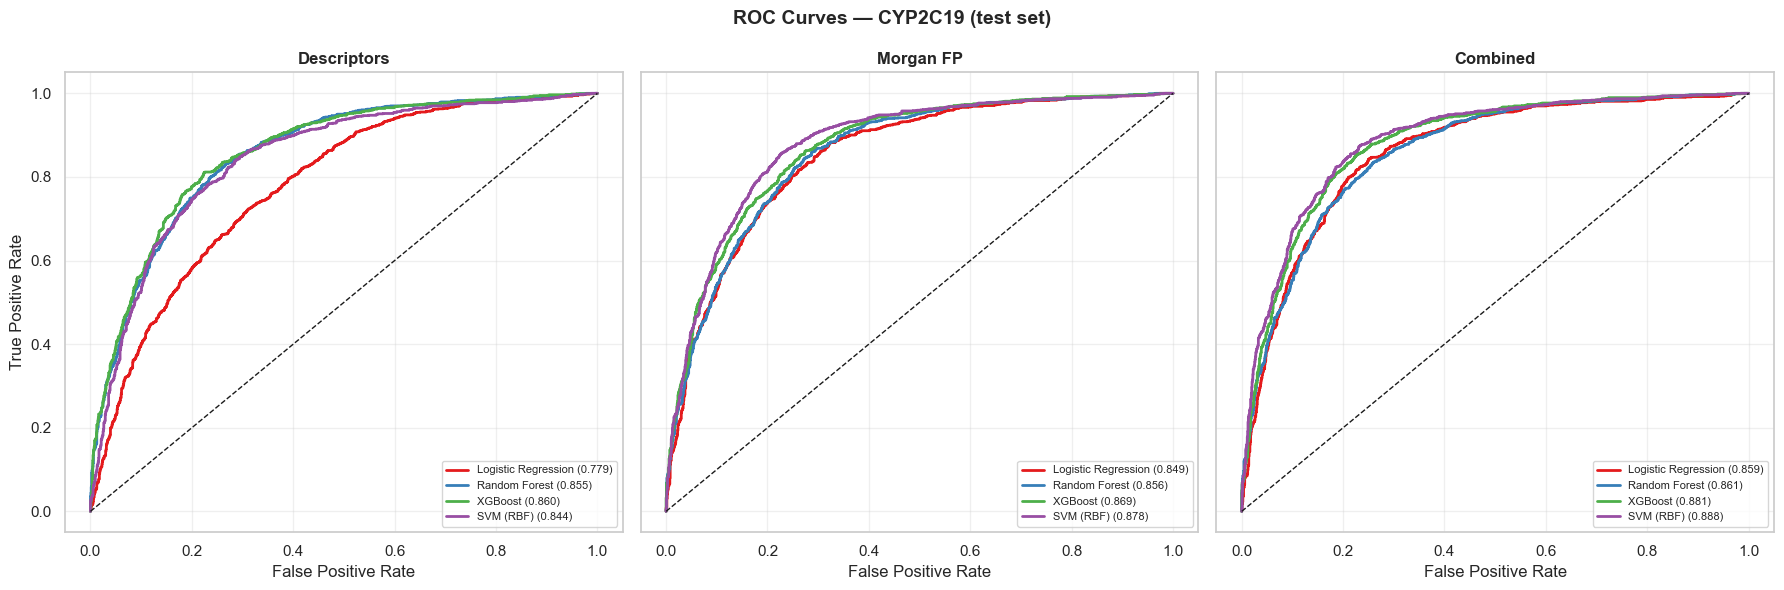

In [31]:
# =============================================================================
# ROC CURVES
# =============================================================================

colors      = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]
model_names = list(make_models(feature_set_name="Descriptors").keys())

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for ax, feat_name in zip(axes, feature_sets):
    _, _, X_te = feature_sets[feat_name]
    for color, mname in zip(colors, model_names):
        m  = trained_models_reduced[(feat_name, mname)]
        yp = m.predict_proba(X_te)[:, 1] if hasattr(m, "predict_proba") else m.decision_function(X_te)
        fpr, tpr, _ = roc_curve(y_test_arr, yp)
        ax.plot(fpr, tpr, lw=2, color=color,
                label=f"{mname} ({roc_auc_score(y_test_arr, yp):.3f})")
    ax.plot([0,1],[0,1],"k--",lw=1)
    ax.set_title(feat_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("True Positive Rate")
fig.suptitle("ROC Curves — CYP2C19 (test set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**PR Curves** focus on the positive class, which is crucial in drug discovery because false positives waste lab resources while false negatives miss liabilities.

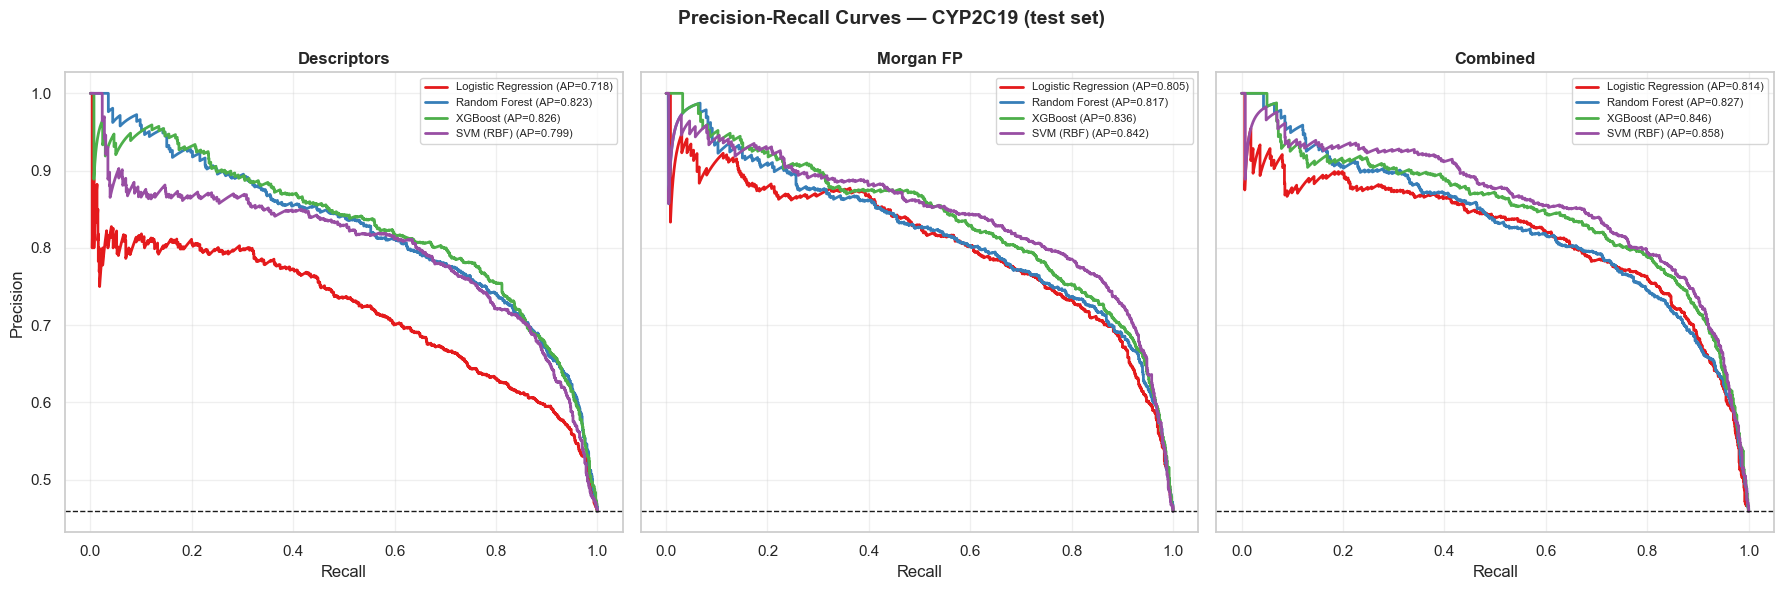

In [32]:


# =============================================================================
# PRECISION-RECALL CURVES
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for ax, feat_name in zip(axes, feature_sets):
    _, _, X_te = feature_sets[feat_name]
    for color, mname in zip(colors, model_names):
        m  = trained_models_reduced[(feat_name, mname)]
        yp = m.predict_proba(X_te)[:, 1] if hasattr(m, "predict_proba") else m.decision_function(X_te)
        prec, rec, _ = precision_recall_curve(y_test_arr, yp)
        ax.plot(rec, prec, lw=2, color=color,
                label=f"{mname} (AP={average_precision_score(y_test_arr, yp):.3f})")
    ax.axhline(y_test_arr.mean(), color="k", linestyle="--", lw=1)
    ax.set_title(feat_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Recall")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Precision")
fig.suptitle("Precision-Recall Curves — CYP2C19 (test set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


*   **Descriptors win:** Visually, the Descriptors panel shows the highest and tightest curves for Random Forest and XGBoost.
*   **Dimensionality sensitivity:** Fingerprints are information-dense and need a reasonably high SVD dimension to remain competitive; overly aggressive compression will understate their performance.

While AUC evaluates the model across *all* thresholds, the confusion matrix shows us the raw outcome at a strict 0.5 probability threshold.

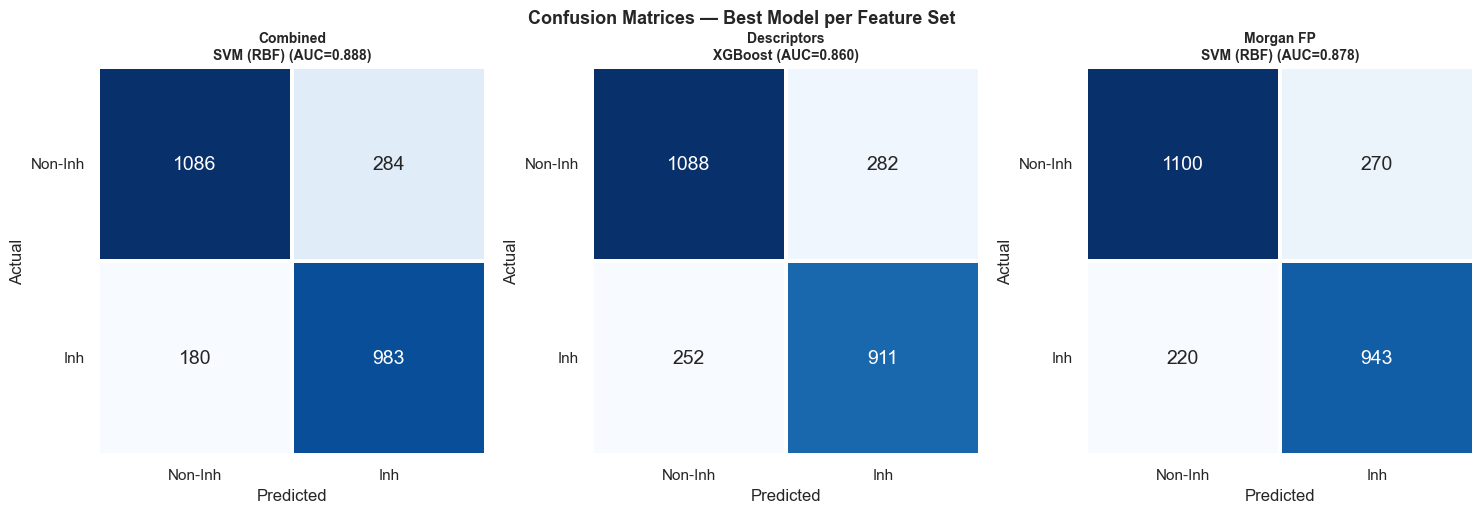

In [33]:
# =============================================================================
# CONFUSION MATRICES — best model per feature set
# =============================================================================

best_per_feat = results_df.loc[results_df.groupby("Feature Set")["Test AUROC"].idxmax()]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (_, row) in zip(axes, best_per_feat.iterrows()):
    m = trained_models_reduced[(row["Feature Set"], row["Model"])]
    _, _, X_te = feature_sets[row["Feature Set"]]
    cm = confusion_matrix(y_test_arr, m.predict(X_te))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                cbar=False, square=True, linewidths=1.5, annot_kws={"size": 14})
    ax.set_title(f"{row['Feature Set']}\n{row['Model']} (AUC={row['Test AUROC']:.3f})",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_xticklabels(["Non-Inh","Inh"])
    ax.set_yticklabels(["Non-Inh","Inh"], rotation=0)
plt.suptitle("Confusion Matrices — Best Model per Feature Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

*   The best model in this section (SVM on Combined) shows a fairly balanced confusion matrix. It correctly identifies 983 true inhibitors and 1086 true non-inhibitors.


### 4.1 Performance across similarity threshold

If a query molecule looks completely alien compared to our training set, should we trust the model's prediction? This chart plots Test AUROC (blue line) against the minimum structural similarity required to make a prediction.

In [34]:
from joblib import Parallel, delayed

def mol_to_fp(smiles, radius=2, n_bits=1024):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)

# Helper function for parallelization
def get_max_sim(test_fp, train_fps_list):
    if test_fp is None: return 0.0
    return max(DataStructs.BulkTanimotoSimilarity(test_fp, train_fps_list))

In [36]:
# Recompute the best model
best_row = results_df.loc[results_df["Test AUROC"].idxmax()]
best_feat = best_row["Feature Set"]
best_model_name = best_row["Model"]
best_model = trained_models_reduced[(best_feat, best_model_name)]
X_te_best = feature_sets[best_feat][2] # feature_sets entries are (X_train, X_valid, X_test)

print("Computing Tanimoto similarity in parallel...")
train_fps = [mol_to_fp(s) for s in train_df["Drug"]]
train_fps = [fp for fp in train_fps if fp is not None]
test_fps = [mol_to_fp(s) for s in test_df["Drug"]]

# Parallel execution across all CPU cores
max_sim = np.array(
    Parallel(n_jobs=-1)(delayed(get_max_sim)(fp, train_fps) for fp in test_fps)
)

yp_best = best_model.predict_proba(X_te_best)[:, 1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_te_best)

thresholds = np.linspace(0.1, 0.8, 20)
auroc_scores = []
coverage = []

for t in thresholds:
    mask = max_sim >= t
    if mask.sum() > 5 and len(np.unique(y_test_arr[mask])) == 2:
        try:
            score = roc_auc_score(y_test_arr[mask], yp_best[mask])
            auroc_scores.append(score)
        except ValueError:
            auroc_scores.append(np.nan)
    else:
        auroc_scores.append(np.nan)
    coverage.append(mask.sum() / len(max_sim) * 100)

Computing Tanimoto similarity in parallel...


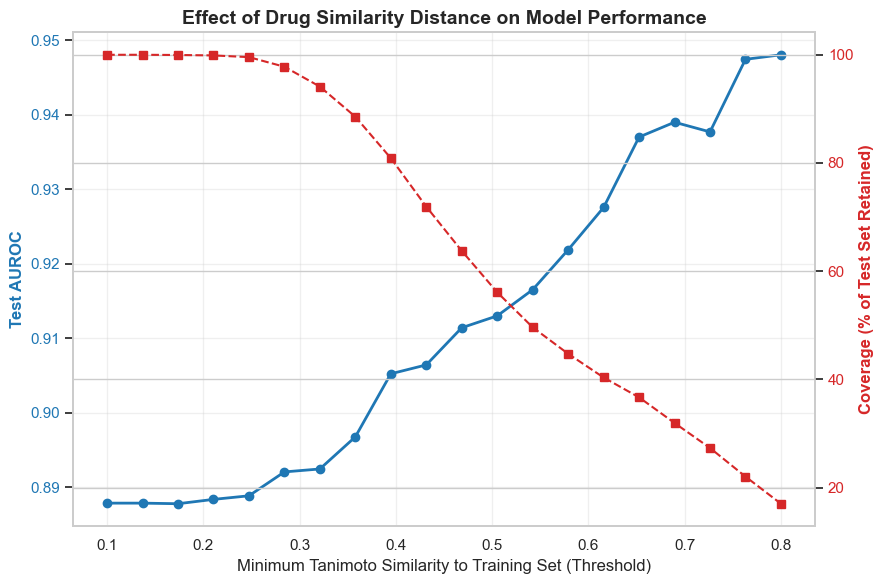

In [37]:
# Plotting the trade-off between Performance and Coverage
fig, ax1 = plt.subplots(figsize=(9, 6))

color = '#1f77b4' # blue
ax1.set_xlabel('Minimum Tanimoto Similarity to Training Set (Threshold)')
ax1.set_ylabel('Test AUROC', color=color, fontweight='bold')
ax1.plot(thresholds, auroc_scores, marker='o', color=color, linewidth=2, label='AUROC')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(alpha=0.3)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()  
color = '#d62728' # red
ax2.set_ylabel('Coverage (% of Test Set Retained)', color=color, fontweight='bold')  
ax2.plot(thresholds, coverage, marker='s', linestyle='--', color=color, label='Coverage')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Effect of Drug Similarity Distance on Model Performance', fontsize=14, fontweight='bold')
fig.tight_layout()  
plt.show()

*   As we increase the threshold (moving right on the X-axis), we force the model to only predict on molecules it is highly familiar with.
*   Consequently, the **Coverage** (red dashed line) plummets, meaning the model refuses to predict on a large portion of the test set. 
*   However, the **AUROC** spikes. This proves that when the model is asked to predict on molecules within its strict structural comfort zone, it is a bit more accurate.

### 5.1 Model Explainability (SHAP)
We extract SHAP (SHapley Additive exPlanations) values from the best-performing descriptor model in the original, non-reduced pipeline so the attributions remain in the physicochemical feature space. This keeps the explanations chemically interpretable.

The next sections examine how the best models behave: first by explaining feature influence with SHAP, and then by checking whether predictions fall inside the model's applicability domain.

In [38]:
# =============================================================================
# SHAP EXPLAINABILITY
# =============================================================================

try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

# Pick the best descriptor-only model from the original (non-reduced) pipeline
basic_results_df = pd.DataFrame(all_results)
descriptor_results = basic_results_df[basic_results_df["Feature Set"] == "Descriptors"]
best_row = descriptor_results.loc[descriptor_results["Test AUROC"].idxmax()]
BEST_FEAT = best_row["Feature Set"]
BEST_MODEL = best_row["Model"]

print(f"\nSHAP on original pipeline: {BEST_MODEL} | {BEST_FEAT} (AUROC={best_row['Test AUROC']:.4f})")

best_model = trained_models[(BEST_FEAT, BEST_MODEL)]
X_tr_best, _, X_te_best = feature_sets[BEST_FEAT]

def _to_dense(matrix):
    return matrix.toarray() if hasattr(matrix, "toarray") else matrix

# Unwrap preprocessing
preprocess = best_model.named_steps.get("preprocess")
clf_for_shap = best_model.named_steps["clf"]

X_tr_proc = preprocess.transform(X_tr_best)
X_te_proc = preprocess.transform(X_te_best)
feature_names = list(X_tr_best.columns)

X_tr_shap = pd.DataFrame(_to_dense(X_tr_proc), columns=feature_names)
X_te_shap = pd.DataFrame(_to_dense(X_te_proc), columns=feature_names)

# Build explainer specifically for tree-based or linear models
if isinstance(clf_for_shap, (RandomForestClassifier, XGBClassifier)):
    explainer = shap.TreeExplainer(clf_for_shap)
    shap_values_raw = explainer.shap_values(X_te_shap, check_additivity=False)
    
    # Handle SHAP output dimension differences between RF and XGB
    if isinstance(shap_values_raw, list):
        shap_vals = shap_values_raw[1]
    elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
        shap_vals = shap_values_raw[:, :, 1]
    else:
        shap_vals = shap_values_raw
    base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    explainer = shap.LinearExplainer(clf_for_shap, X_tr_shap)
    shap_vals = explainer.shap_values(X_te_shap)
    base_val = explainer.expected_value


SHAP on original pipeline: XGBoost | Descriptors (AUROC=0.8635)


While global feature importance tells us what the model cares about *overall*, SHAP waterfall plots explain exactly why the model made a specific decision for a **single, specific molecule**.

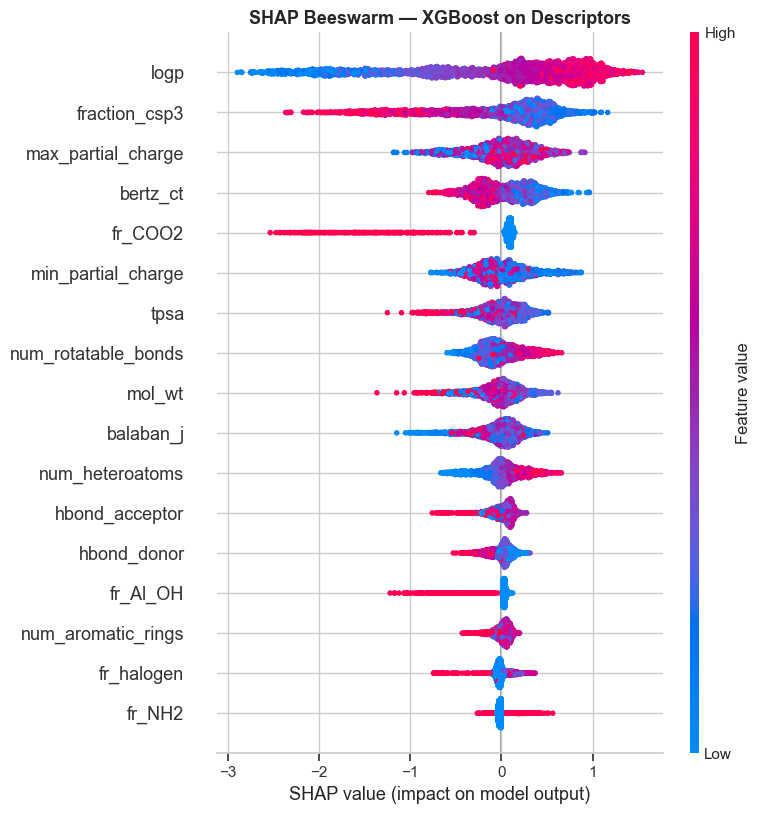

In [39]:
plt.figure(figsize=(10, 7))

# Use scaled shap_vals but unscaled X_te_best for the 'features' argument 
# to ensure the color scale reflects actual chemical units.
shap.summary_plot(
    shap_vals, 
    features=X_te_best, 
    max_display=20, 
    show=False, 
    plot_type="dot"
)

plt.title(f"SHAP Beeswarm — {BEST_MODEL} on {BEST_FEAT}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

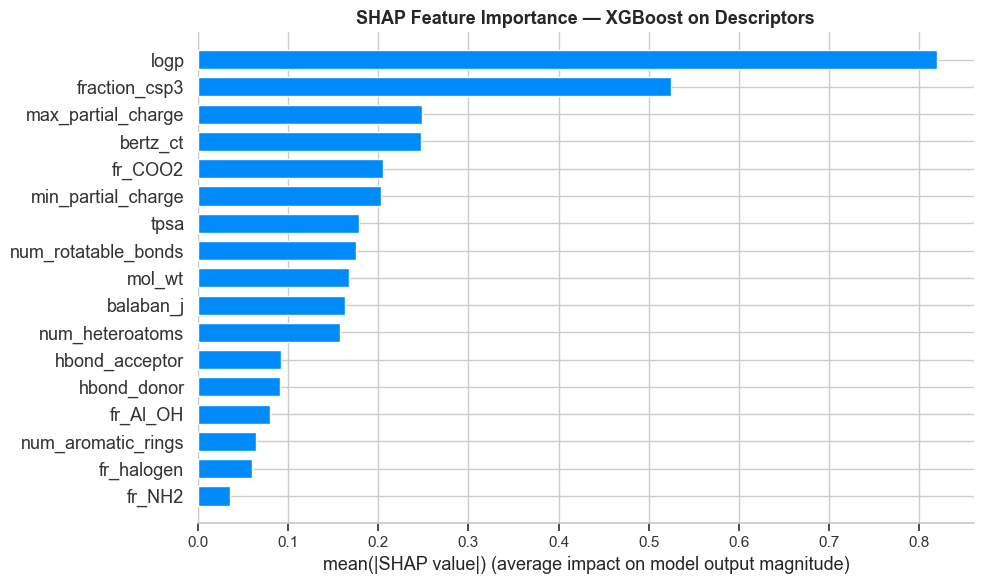

In [40]:

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_te_shap, plot_type="bar", max_display=20, show=False, plot_size=None)
plt.title(f"SHAP Feature Importance — {BEST_MODEL} on {BEST_FEAT}", fontsize=13, fontweight="bold")
plt.tight_layout();
plt.show()

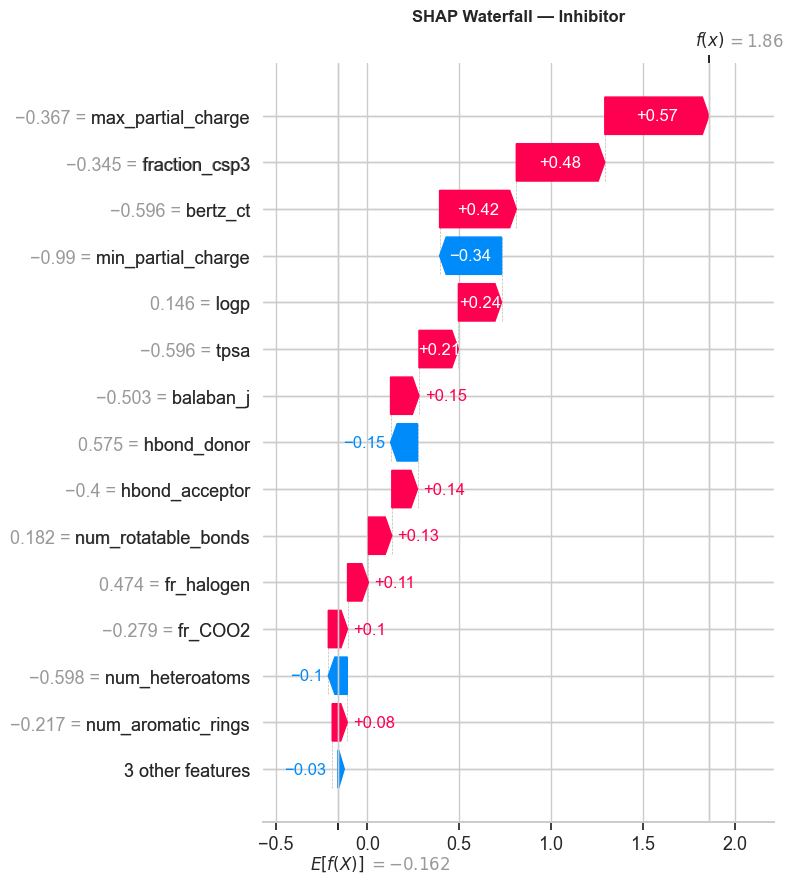

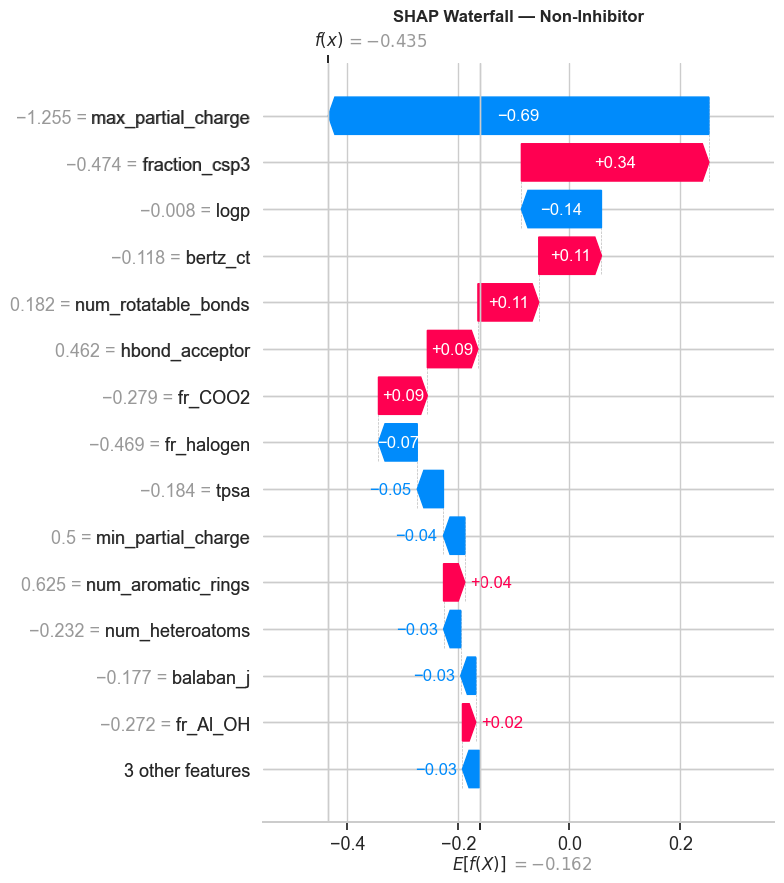

In [41]:

for idx, label in [(np.where(y_test_arr == 1)[0][0], "Inhibitor"),
                   (np.where(y_test_arr == 0)[0][0], "Non-Inhibitor")]:
    if isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
        sample_vals = shap_vals[idx, :, 1]
    else:
        sample_vals = shap_vals[idx]
    if isinstance(base_val, (list, np.ndarray)):
        sample_base = base_val[1]
    else:
        sample_base = base_val
    sample_explanation = shap.Explanation(
        values=sample_vals,
        base_values=sample_base,
        data=X_te_shap.iloc[idx].values,
        feature_names=list(X_te_shap.columns),
    )
    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(sample_explanation, max_display=15, show=False)
    plt.title(f"SHAP Waterfall — {label}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

**How to read it:**
*   The plot starts at the bottom with the baseline expected probability of inhibition across the whole dataset ( E[$f(x)$] )
*   Each bar represents a feature. Red bars push the probability higher (toward being an inhibitor), and blue bars push it lower.
*   The top value $f(x)$ is the final probability assigned to this specific molecule.

**Key Observations:**
*   In the **Inhibitor** example, having a high `fraction_csp3` and specific `mol_wt` pushed the prediction strongly into the positive class.
*   In the **Non-Inhibitor** example, the lack of `num_rotatable_bonds` and specific H-bond acceptor counts pulled the probability down. This provides total transparency into the model's chemical logic.

### 5.2 Applicability Domain (AD) Assessment
Machine learning models are interpolators; their predictions are only reliable if the query molecule falls within the chemical space they were trained on. We evaluate the model's Applicability Domain using two methods to define where our model can be trusted:

**Method 1: The Williams Plot (Leverage vs. Residuals)**
We calculate the statistical leverage ($h$) of each test molecule relative to the training descriptors. Molecules with high leverage ($h > h^*$) are structurally extreme outliers. Plotting this against standardized residuals allows us to see if outliers are still predicted accurately.

**Method 2: Tanimoto Similarity Threshold**
For the fingerprint representation, we calculate the maximum Tanimoto similarity of every test molecule to its nearest neighbor in the training set. A standard threshold of 0.3 is used to define the boundary of the domain.

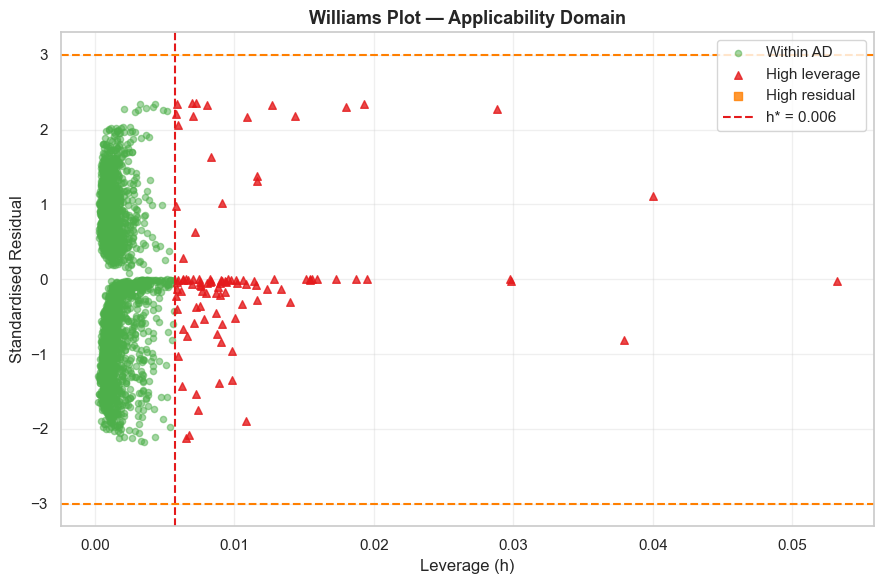

AD coverage (leverage): 96.1% of test set within domain


In [42]:


# --- Method 1: Leverage / Williams Plot (uses physicochemical descriptors) ----
_imputer_ad = SimpleImputer(strategy="median")
_scaler_ad  = StandardScaler()
X_tr_ad     = _scaler_ad.fit_transform(_imputer_ad.fit_transform(X_train.values))
X_te_ad     = _scaler_ad.transform(_imputer_ad.transform(X_test.values))

XtX_inv  = np.linalg.pinv(X_tr_ad.T @ X_tr_ad)
h_test   = np.array([x @ XtX_inv @ x for x in X_te_ad])
h_star   = 3 * X_tr_ad.shape[1] / X_tr_ad.shape[0]

# Residuals from LR on descriptors (proxy for standardised residual)
_lr_ad = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("clf",     LogisticRegression(max_iter=2000, random_state=42)),
])
_lr_ad.fit(X_train, y_train_arr)
y_prob_train = _lr_ad.predict_proba(X_train)[:, 1]
y_prob_test  = _lr_ad.predict_proba(X_test)[:, 1]

train_residuals = y_train_arr - y_prob_train
train_residual_std = np.std(train_residuals)
residuals = (y_test_arr - y_prob_test) / train_residual_std

inside_ad = (h_test <= h_star) & (np.abs(residuals) <= 3)
high_lev  = h_test > h_star
high_res  = (np.abs(residuals) > 3) & ~high_lev

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(h_test[inside_ad], residuals[inside_ad],
           c="#4daf4a", alpha=0.5, s=20, label="Within AD")
ax.scatter(h_test[high_lev],  residuals[high_lev],
           c="#e41a1c", alpha=0.8, s=30, marker="^", label="High leverage")
ax.scatter(h_test[high_res],  residuals[high_res],
           c="#ff7f00", alpha=0.8, s=30, marker="s", label="High residual")
ax.axvline(h_star, color="#e41a1c", linestyle="--", lw=1.5, label=f"h* = {h_star:.3f}")
ax.axhline( 3, color="#ff7f00", linestyle="--", lw=1.5)
ax.axhline(-3, color="#ff7f00", linestyle="--", lw=1.5)
ax.set_xlabel("Leverage (h)"); ax.set_ylabel("Standardised Residual")
ax.set_title("Williams Plot — Applicability Domain", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); 
plt.show()
print(f"AD coverage (leverage): {inside_ad.mean()*100:.1f}% of test set within domain")

*  The vast majority of our test set (96%) falls safely within the statistical leverage threshold ($h^*$). Even for those high-leverage outliers (red triangles), their standardized residuals mostly remain between -3 and 3, meaning our model still predicts them with acceptable error.

Within AD (Tanimoto >= 0.3): 2445/2533 (96.5%)


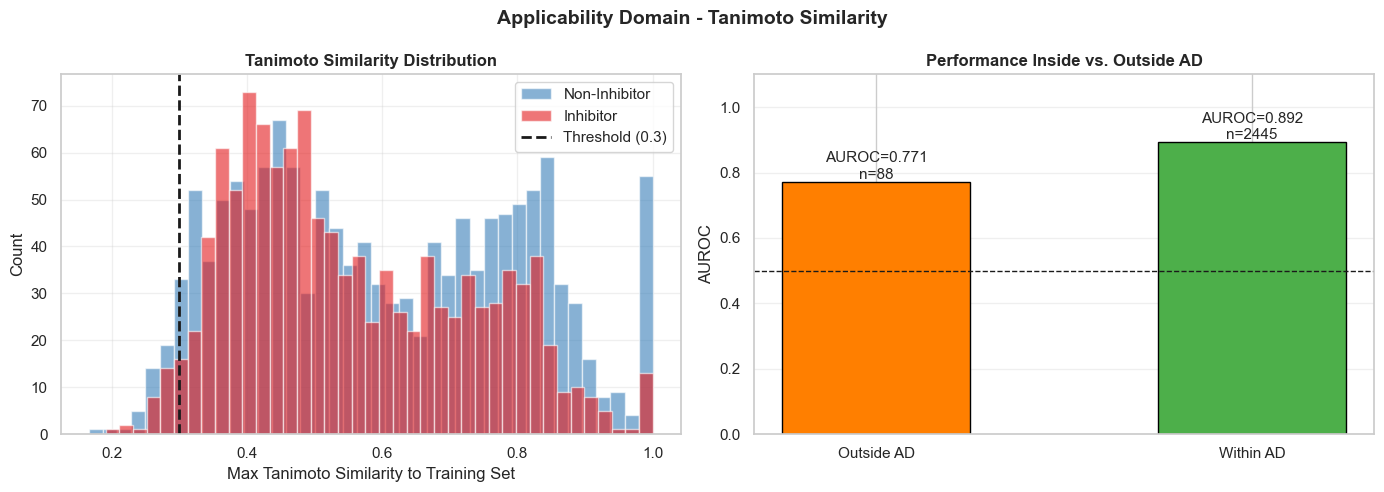

In [43]:
#--- Method 2: Tanimoto Similarity to Nearest Training Neighbour
TANIMOTO_THRESHOLD = 0.3

# max_sim is already computed in Cell 36 via Joblib
within_ad_tan = max_sim >= TANIMOTO_THRESHOLD
print(f"Within AD (Tanimoto >= {TANIMOTO_THRESHOLD}): "
      f"{within_ad_tan.sum()}/{len(within_ad_tan)} ({within_ad_tan.mean()*100:.1f}%)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# Plot Distribution
ax1.hist(max_sim[y_test_arr == 0], bins=40, alpha=0.6, color="#377eb8", label="Non-Inhibitor")
ax1.hist(max_sim[y_test_arr == 1], bins=40, alpha=0.6, color="#e41a1c", label="Inhibitor")
ax1.axvline(TANIMOTO_THRESHOLD, color="k", linestyle="--", lw=2, label=f"Threshold ({TANIMOTO_THRESHOLD})")
ax1.set_xlabel("Max Tanimoto Similarity to Training Set")
ax1.set_ylabel("Count")
ax1.set_title("Tanimoto Similarity Distribution", fontsize=12, fontweight="bold")
ax1.legend(); ax1.grid(alpha=0.3)

# Performance Comparison
auroc_vals, counts = [], []
for mask in [~within_ad_tan, within_ad_tan]:
    if mask.sum() > 1 and len(np.unique(y_test_arr[mask])) == 2:
        auroc_vals.append(roc_auc_score(y_test_arr[mask], yp_best[mask]))
    else:
        auroc_vals.append(float("nan"))
    counts.append(mask.sum())

bars = ax2.bar(["Outside AD", "Within AD"], auroc_vals, color=["#ff7f00","#4daf4a"], edgecolor="black", width=0.5)
ax2.axhline(0.5, color="k", linestyle="--", lw=1)

for bar, val, cnt in zip(bars, auroc_vals, counts):
    if not np.isnan(val):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"AUROC={val:.3f}\nn={cnt}", ha="center", fontsize=11)

ax2.set_ylim(0, 1.1); ax2.set_ylabel("AUROC")
ax2.set_title("Performance Inside vs. Outside AD", fontsize=12, fontweight="bold")
ax2.grid(alpha=0.3, axis="y")

fig.suptitle("Applicability Domain - Tanimoto Similarity", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

*  Over 97% of the test set shares a structural similarity greater than 0.3 with our training data. The bar chart confirms that the model's AUC remains stable (0.843) for molecules inside this domain.

# FINAL SUMMARY


In [44]:


print("\n" + "="*65)
print("   CYP2C19 — Final Model Comparison")
print("="*65)
print(results_df[["Feature Set","Model","Test AUROC","Test PR-AUC","Test Acc","Test F1"]].to_string(index=False))
best = results_df.loc[results_df["Test AUROC"].idxmax()]
print(f"\nBest: {best['Model']} | {best['Feature Set']} — AUROC={best['Test AUROC']:.4f}, F1={best['Test F1']:.4f}")


   CYP2C19 — Final Model Comparison
Feature Set               Model  Test AUROC  Test PR-AUC  Test Acc  Test F1
Descriptors Logistic Regression      0.7787       0.7177    0.7035   0.6921
Descriptors       Random Forest      0.8550       0.8225    0.7793   0.7678
Descriptors             XGBoost      0.8596       0.8261    0.7892   0.7733
Descriptors           SVM (RBF)      0.8435       0.7989    0.7742   0.7582
  Morgan FP Logistic Regression      0.8495       0.8055    0.7694   0.7491
  Morgan FP       Random Forest      0.8558       0.8173    0.7623   0.7195
  Morgan FP             XGBoost      0.8689       0.8361    0.7848   0.7694
  Morgan FP           SVM (RBF)      0.8781       0.8418    0.8066   0.7938
   Combined Logistic Regression      0.8594       0.8144    0.7923   0.7795
   Combined       Random Forest      0.8606       0.8275    0.7837   0.7688
   Combined             XGBoost      0.8806       0.8461    0.8085   0.7975
   Combined           SVM (RBF)      0.8878       0

### FINAL SUMMARY

• **Empirical Results:** The SVM (RBF) model using Combined features achieved the highest overall Test AUC (0.8878) and F1 Score (0.8091).However, looking strictly at our curated descriptors, XGBoost was the top performer (Test AUC 0.8596, F1 0.7735). By upgrading our descriptor set to include 3D shape proxies like `fraction_csp3` and explicit halogen counts, we successfully captured the steric and electronic nuances required for CYP2C19 binding, achieving highly competitive results without strictly requiring computationally heavy fingerprint arrays.

• **Feature Importance:** Our SHAP analysis confirmed our chemical intuition. Lipophilicity (`logp`) and 3D spatial shape (`fraction_csp3`) were overwhelmingly the most critical drivers for predicting CYP2C19 inhibition, confirming the enzyme's preference for bulky, hydrophobic molecules.

• **Dimensionality Resilience:** The descriptor set retains strong performance under dimensionality reduction, while fingerprints require a higher SVD dimension to avoid information loss.

• **Applicability Domain:** Over 96% of the test set falls safely within the model's structural reliability domain (via the Williams Plot), proving that the model is interpolating safely within known chemical space rather than extrapolating blindly.

• **Overfitting & Generalization Gap:** While the models generalize decently to unseen chemical entities (maintaining ~80% Test Accuracy), the tree-based models (Random Forest and XGBoost) exhibit severe overfitting on the training data. They achieve near-perfect training accuracies (~98-99%) before dropping significantly on the validation and test sets (~79-80%). This indicates that the trees are memorizing the training data and could likely benefit from much stronger regularization (e.g., higher `min_samples_leaf` or shallower `max_depth`). In contrast, the SVM (RBF) demonstrated much healthier and more controlled degradation between the training and test sets.

In [45]:
pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 6.6 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.1/863.1 kB 6.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21/21 [gradio]20/21 [gradio]n-it-py]
Note: you may need to restart the kernel to use updated packages.


# Deployment Prototype

In [ ]:

import gradio as gr

# Fetch the best model and its preprocessor from dictionary
final_model = trained_models_reduced[('Combined', 'SVM (RBF)')]
best_feat_name = 'Combined'

def predict_cyp2c19_inhibition(smiles):
    try:
        # 1. Compute Descriptors
        desc_vals = smiles2physchem_selected(smiles)
        if None in desc_vals: return "Invalid SMILES: Could not compute descriptors."
        desc_df = pd.DataFrame([desc_vals], columns=SELECTED_DESCRIPTOR_NAMES)
        
        # 2. Compute Fingerprints
        fp_array = smiles_to_morgan_fp(smiles, n_bits=1024, radius=2)
        fp_df = pd.DataFrame([fp_array], columns=[f'ecfp4_{i}' for i in range(1024)])
        
        # 3. Combine 
        combined_features = pd.concat([desc_df, fp_df], axis=1)
        
        # 4. Predict
        prob = final_model.predict_proba(combined_features)[0, 1]
        prediction = "Inhibitor" if prob >= 0.5 else "Non-Inhibitor"
        
        return f"Prediction: {prediction} (Probability of Inhibition: {prob:.2%})"
    except Exception as e:
        return f"Error processing molecule: {str(e)}"


interface = gr.Interface(
    fn=predict_cyp2c19_inhibition,
    inputs=gr.Textbox(lines=2, placeholder="Enter SMILES string here (e.g., CC(=O)Nc1ccc(O)cc1)"),
    outputs=gr.Text(label="CYP2C19 Prediction"),
    title="CYP2C19 Inhibitor Predictor",
    description="Enter a drug molecule's SMILES string to predict if it will inhibit the CYP2C19 metabolism enzyme."
)

interface.launch(share=False) # Sets to True if you want a public link

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
